In [1]:
from gorgo import infer, condition, draw_from, flip, keep_deterministic, mem, factor
from gorgo.hashable import hashabledict
from gorgo.distributions.builtin_dists import Uniform, Beta
from gorgo.distributions import Mixture

from model import Utterance, Instance, Kind, meaning, literal_listener, speaker, pragmatic_listener

import numpy as np
from gorgo.inference import MaximumMarginalAPosteriori
import pickle

from collections import namedtuple
import math
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from scipy.stats import pearsonr

# Define helper functions

In [ ]:
## convert gorgo dist to df for plotting
@keep_deterministic
def dist_to_df(dist) -> pd.DataFrame:
    
    # validate input
    if not hasattr(dist, 'support') or not hasattr(dist, 'probabilities'):
        raise AttributeError("Distribution must have support and probabilities")
    
    # create dataframe based on support type
    if isinstance(dist.support[0], float): 
        df_dist = pd.DataFrame({
            'Element': dist.support,
            'Probability': dist.probabilities
        })
    else: 
        # for complex support, expand into multiple columns
        df_dist = pd.DataFrame(dist.support)
        df_dist['Probability'] = dist.probabilities
    
    return df_dist

# Set up Study 6 structure

In [ ]:
# conditions
conditions = ("generic", "baseline", "specific")

# training trials per condition
generic_condition = (
    (Utterance("Zarpies", "love to eat flowers"), Instance("Zarpie", ("love to eat flowers", ))),
    (Utterance("Zarpies", "have stripes in their hair"), Instance("Zarpie", ("have stripes in their hair", ))),
    (Utterance("Zarpies", "can bounce a ball on their heads"), Instance("Zarpie", ("can bounce a ball on their heads", ))),
    (Utterance("Zarpies", "like to sing"), Instance("Zarpie", ("like to sing", ))),
    (Utterance("Zarpies", "climb tall fences"), Instance("Zarpie", ("climb tall fences", ))),
    (Utterance("Zarpies", "flap their arms when they are happy"), Instance("Zarpie", ("flap their arms when they are happy", ))),
    (Utterance("Zarpies", "have freckles on their feet"), Instance("Zarpie", ("have freckles on their feet", ))),
    (Utterance("Zarpies", "hop over puddles"), Instance("Zarpie", ("hop over puddles", ))),
    (Utterance("Zarpies", "really don't like walking in the mud"), Instance("Zarpie", ("really don't like walking in the mud", ))),
    (Utterance("Zarpies", "draw stars on their knees"), Instance("Zarpie", ("draw stars on their knees", ))),
    (Utterance("Zarpies", "can flip in the air"), Instance("Zarpie", ("can flip in the air", ))),
    (Utterance("Zarpies", "are scared of ladybugs"), Instance("Zarpie", ("are scared of ladybugs", ))),
    (Utterance("Zarpies", "really don't like ice cream"), Instance("Zarpie", ("really don't like ice cream", ))),
    (Utterance("Zarpies", "chase shadows"), Instance("Zarpie", ("chase shadows", ))),
    (Utterance("Zarpies", "babies are wrapped in orange blankets"), Instance("Zarpie", ("babies are wrapped in orange blankets", ))),
    (Utterance("Zarpies", "sleep in tall trees"), Instance("Zarpie", ("sleep in tall trees", )))
)

specific_condition = (
    (Utterance("This Zarpie", "love to eat flowers"), Instance("Zarpie", ("love to eat flowers", ))),
    (Utterance("This Zarpie", "have stripes in their hair"), Instance("Zarpie", ("have stripes in their hair", ))),
    (Utterance("This Zarpie", "can bounce a ball on their heads"), Instance("Zarpie", ("can bounce a ball on their heads", ))),
    (Utterance("This Zarpie", "like to sing"), Instance("Zarpie", ("like to sing", ))),
    (Utterance("This Zarpie", "climb tall fences"), Instance("Zarpie", ("climb tall fences", ))),
    (Utterance("This Zarpie", "flap their arms when they are happy"), Instance("Zarpie", ("flap their arms when they are happy", ))),
    (Utterance("This Zarpie", "have freckles on their feet"), Instance("Zarpie", ("have freckles on their feet", ))),
    (Utterance("This Zarpie", "hop over puddles"), Instance("Zarpie", ("hop over puddles", ))),
    (Utterance("This Zarpie", "really don't like walking in the mud"), Instance("Zarpie", ("really don't like walking in the mud", ))),
    (Utterance("This Zarpie", "draw stars on their knees"), Instance("Zarpie", ("draw stars on their knees", ))),
    (Utterance("This Zarpie", "can flip in the air"), Instance("Zarpie", ("can flip in the air", ))),
    (Utterance("This Zarpie", "are scared of ladybugs"), Instance("Zarpie", ("are scared of ladybugs", ))),
    (Utterance("This Zarpie", "really don't like ice cream"), Instance("Zarpie", ("really don't like ice cream", ))),
    (Utterance("This Zarpie", "chase shadows"), Instance("Zarpie", ("chase shadows", ))),
    (Utterance("This Zarpie", "babies are wrapped in orange blankets"), Instance("Zarpie", ("babies are wrapped in orange blankets", ))),
    (Utterance("This Zarpie", "sleep in tall trees"), Instance("Zarpie", ("sleep in tall trees", )))
)

baseline_condition = ()

In [4]:

# scale up for paper figures
sns.set_context("paper", font_scale=1.5)
                # rc={"font.size":20,
                #              "axes.titlesize":20,
                #              "axes.labelsize":20})   

# condition colors for plotting
condition_colors = {'generic': 'tab:orange', 
                    'baseline': 'tab:green',
                    'specific': 'tab:blue'}

# test feature labels for plotting
feature_labels = {
    'live_caves': 'live in caves',
    'ride_lions': 'ride lions',
    'farm_potatoes': 'farm potatoes',
    'play_banjo': 'play banjos',
    'look_left': 'look to their left when spoken to',
    'clap_three': 'clap three times before entering a room',
    'smile_sad': 'smile when they are sad',
    'chug_syrup': 'chug maple syrup',
    'yell_cats': 'yell at stray cats',
    'go_opera': 'go to the opera',
    'dance_fire': 'dance around a fire on their 10th birthday',
    'sing_songs': 'sing beautiful songs',
    'scream_windows': 'scream out windows',
    'smell_garbage': 'smell garbage for fun',
    'wash_ponds': 'wash their clothes in ponds',
    'paint_hands': 'paint their hands yellow'
}

# Import Study 6 data

In [5]:
# read in df_tidy
df_tidy = pd.read_csv("scratch/study 6/df_tidy.csv")

In [6]:
# get mean prevalence by condition, feature
df_tidy_feature_means = df_tidy.groupby(['condition', 'feature'], observed=True)['prevalence'].agg('mean').reset_index()
df_tidy_feature_means = df_tidy_feature_means.sort_values(by='feature')

# get all test features
all_test_features = df_tidy["feature"].unique()

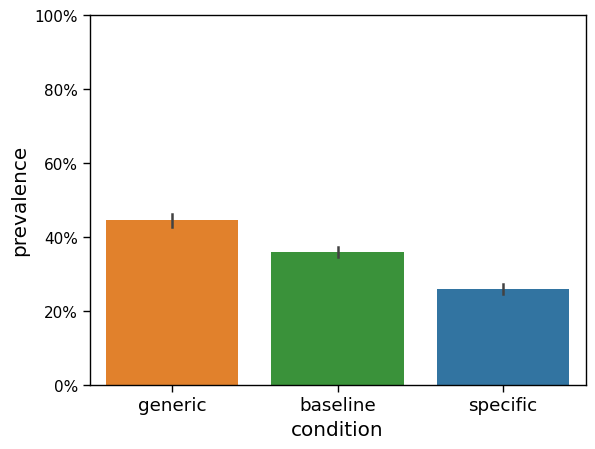

In [7]:
# plot prevalence
g = sns.barplot(data = df_tidy,
                x = 'condition', y = 'prevalence',
                hue = 'condition', palette = condition_colors)
# y-axis percentage 0-1
plt.ylim(0, 1)
g.yaxis.set_major_formatter(PercentFormatter(1))
g.yaxis.set_tick_params(labelsize = 11)

plt.savefig("figs/study 6/prevalence_by_condition.png", bbox_inches = "tight")
plt.show(g)

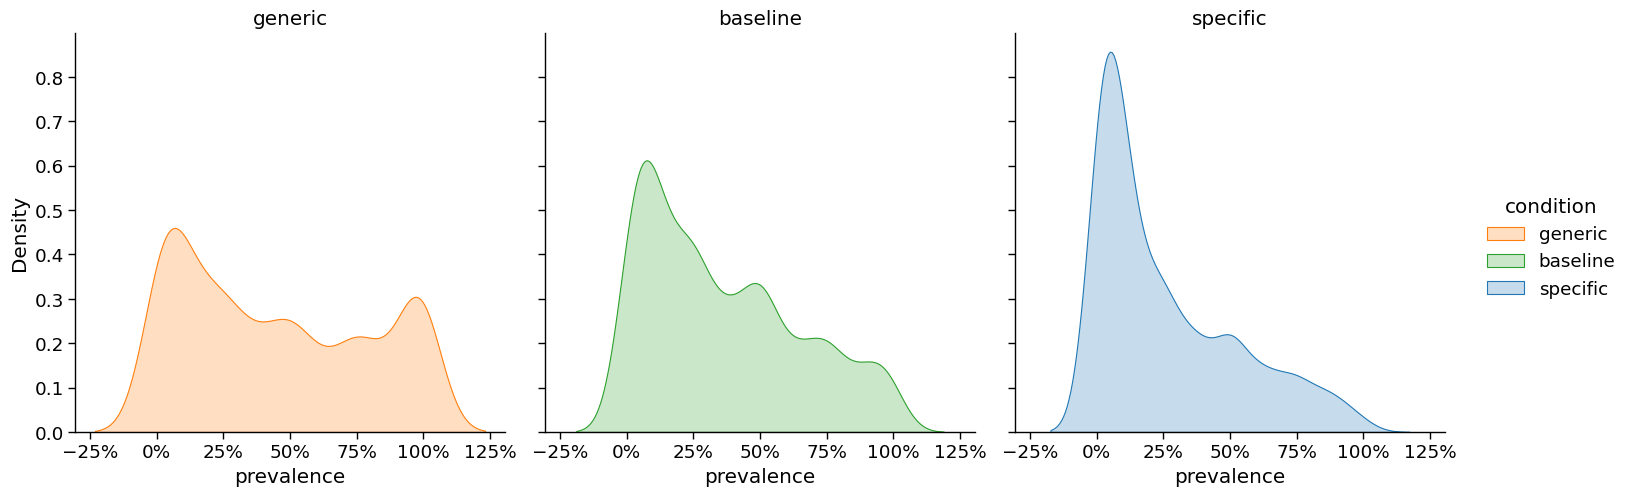

In [8]:
# make plot
g = sns.displot(
    df_tidy, 
    x="prevalence", 
    hue="condition", palette=condition_colors,
    fill=True, 
    col="condition", 
    multiple="layer",
    kind="kde" # density plot
)
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.95)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.savefig("figs/study 6/prevalence_by_condition_density.png", bbox_inches = "tight")

/var/folders/5p/8m9jqqdd581dvm8wc358jtz40000gp/T/ipykernel_72574/3683579716.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])


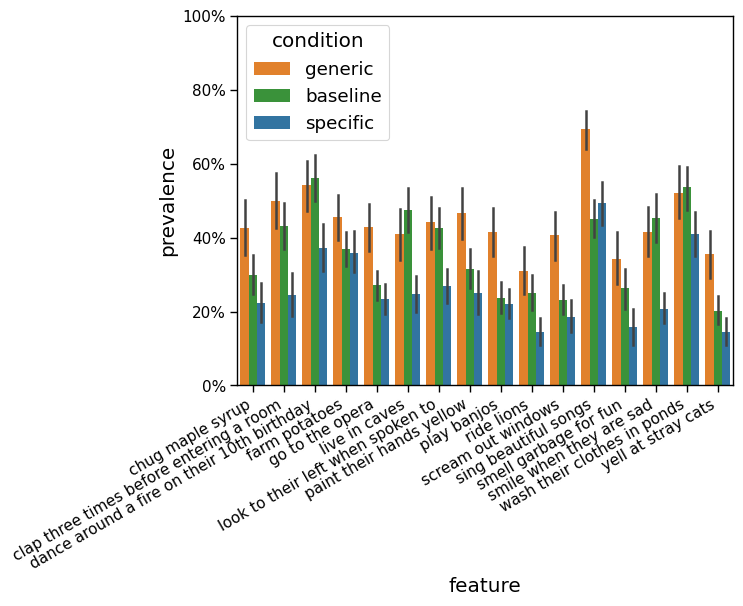

In [9]:
# plot prevalence
g = sns.barplot(data = df_tidy,
                x = 'feature', order=sorted(df_tidy['feature']), # features in alphabetical order
                y = 'prevalence',
                hue = 'condition', palette = condition_colors)
# y-axis percentage 0-1
plt.ylim(0, 1)
g.yaxis.set_major_formatter(PercentFormatter(1))
g.yaxis.set_tick_params(labelsize = 11)
# x-axis rotated long labels
g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])
plt.xticks(rotation=30, ha='right')
g.xaxis.set_tick_params(labelsize = 11)

plt.savefig("figs/study 6/data_condition_by_feature.png", bbox_inches = "tight")
plt.show(g)

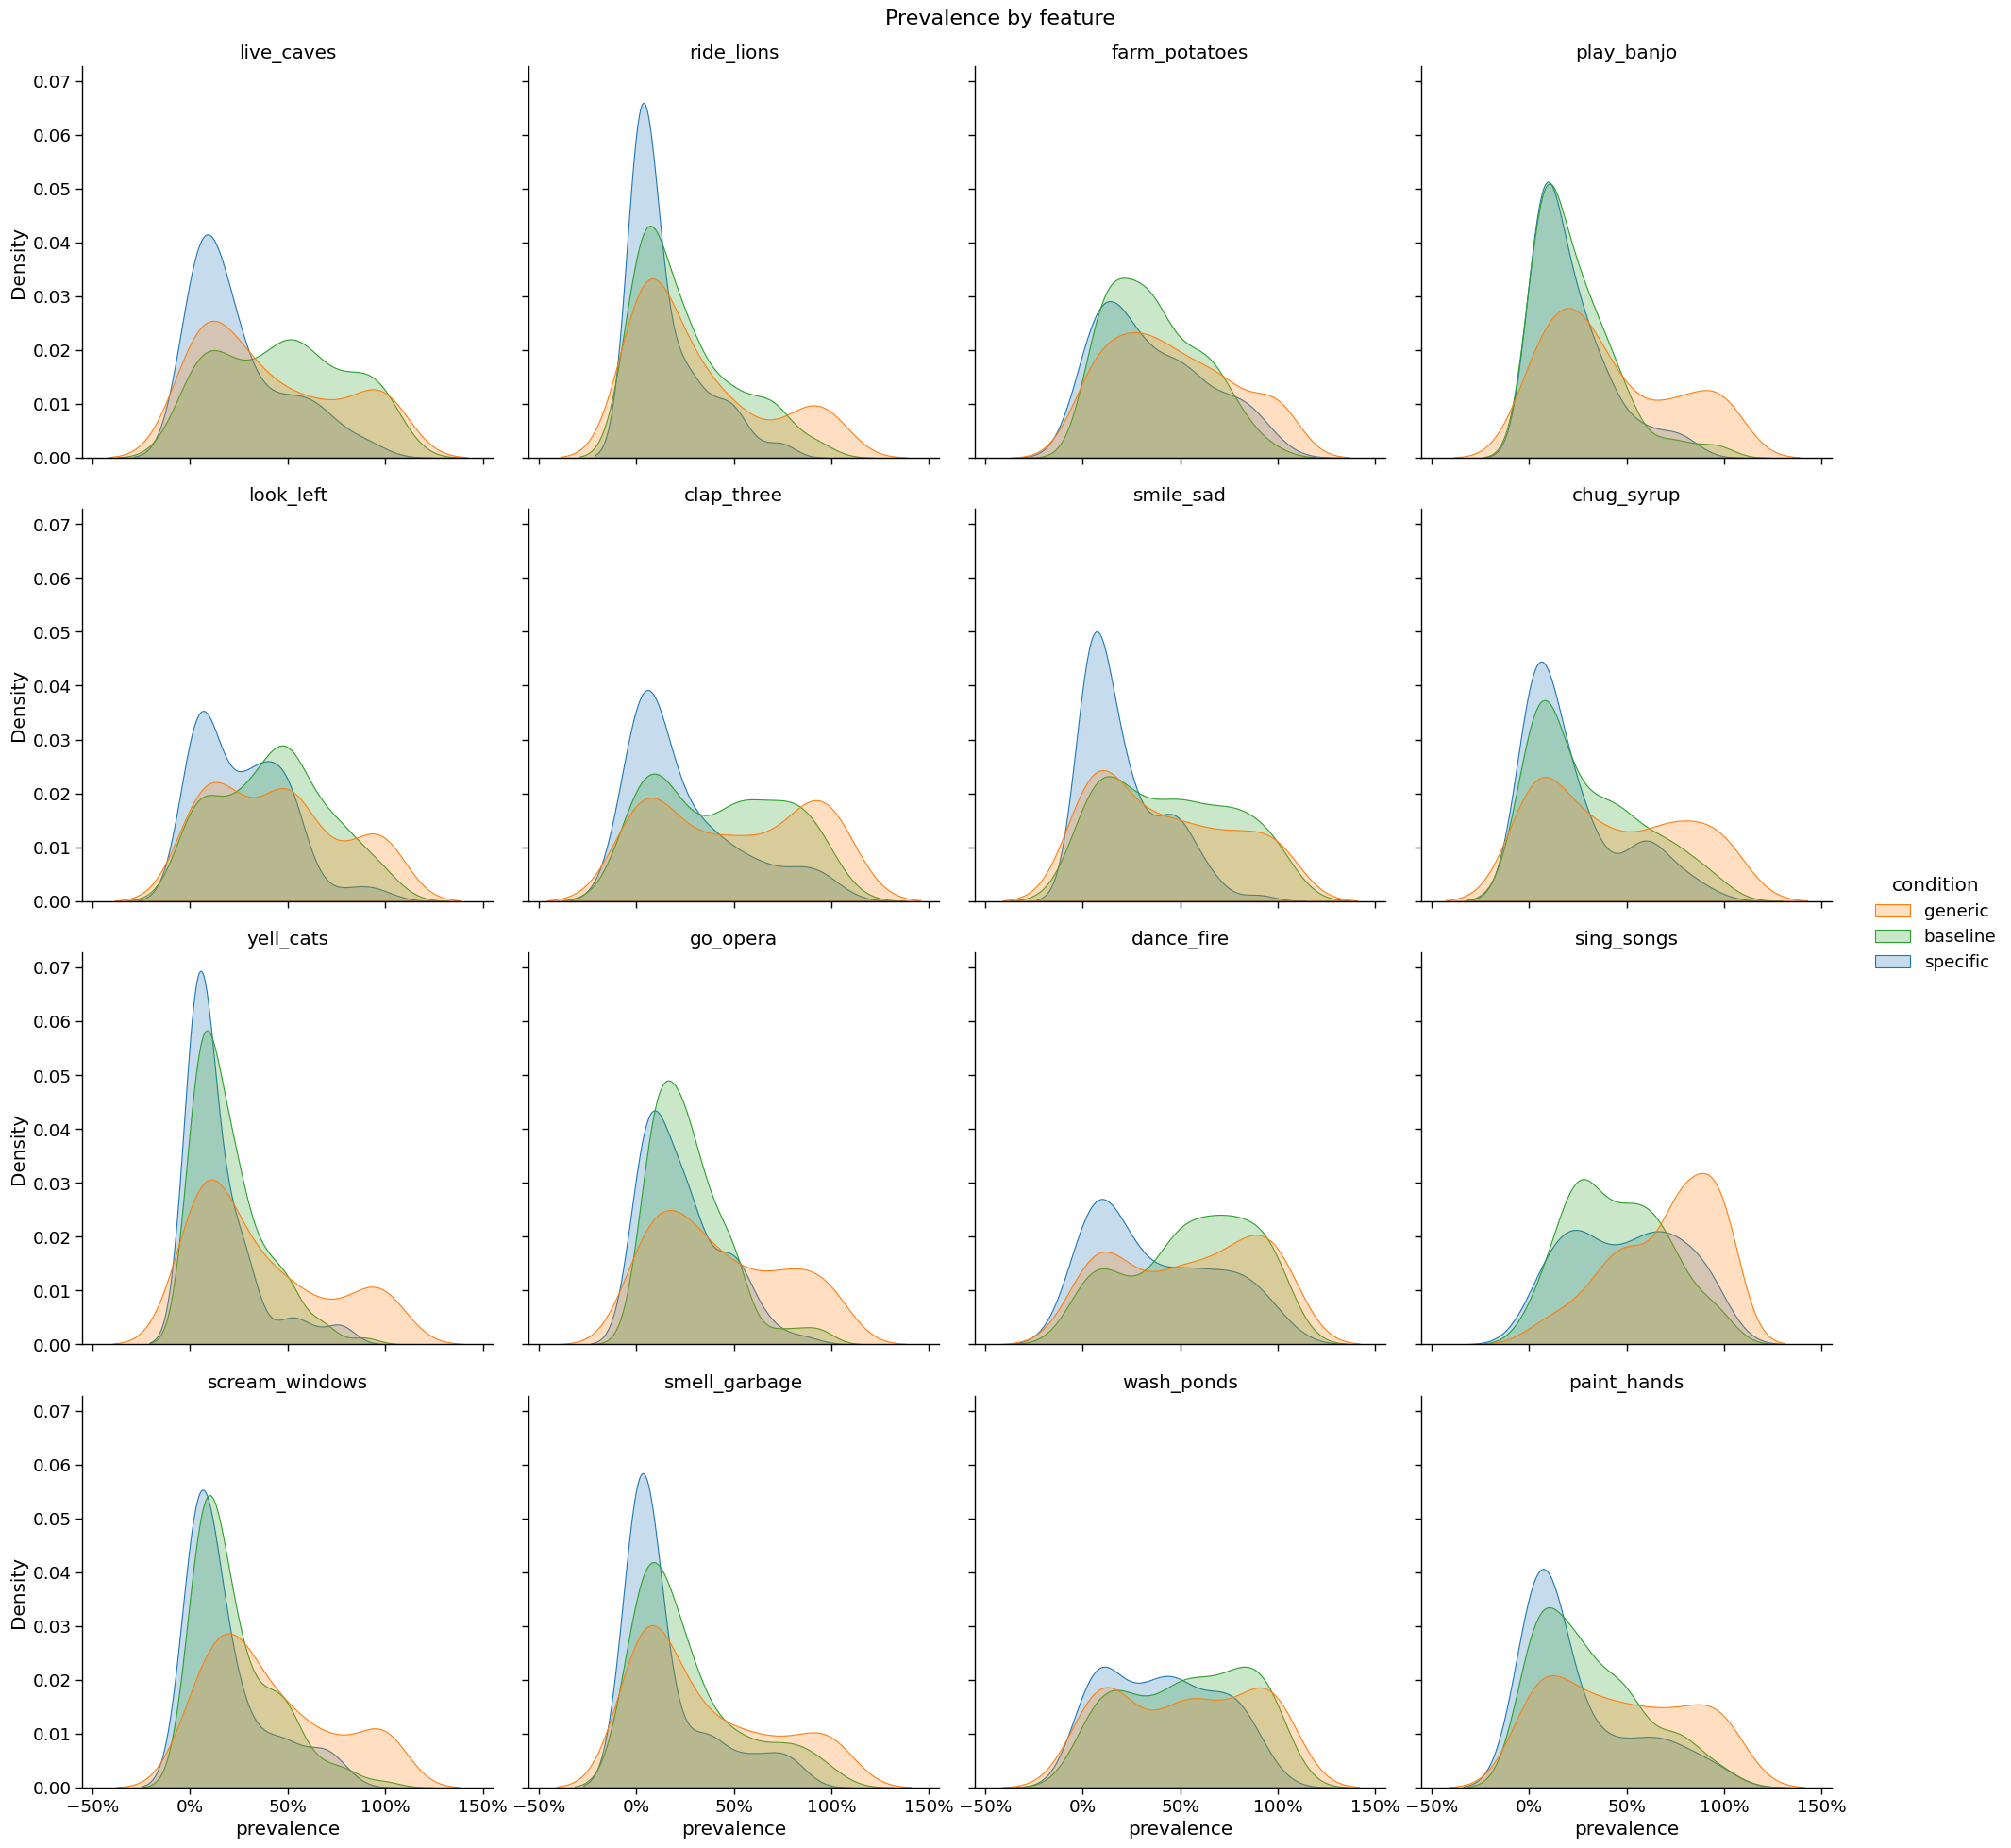

In [10]:
# make plot
g = sns.displot(
    df_tidy, 
    x="prevalence", 
    hue="condition", palette=condition_colors,
    fill=True, 
    col="feature", col_wrap=4,
    multiple="layer",
    kind="kde" # density plot
)
g.fig.suptitle('Prevalence by feature', fontsize=16)
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.95)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.savefig("figs/study 6/prevalence_by_feature.png", bbox_inches = "tight")

# Load model fitted output

from model-study6-1-fit.ipynb

## Coherence

In [11]:
# load pragmatic listener coherence outputs
with open("scratch/study 6/dist_coherence_generic_prag.pkl", "rb") as f: 
    dist_coherence_generic_prag = pickle.load(f)

with open("scratch/study 6/dist_coherence_specific_prag.pkl", "rb") as f:
    dist_coherence_specific_prag = pickle.load(f)

with open("scratch/study 6/dist_coherence_baseline_prag.pkl", "rb") as f:
    dist_coherence_baseline_prag = pickle.load(f)

In [12]:
# load literal listener coherence outputs
with open("scratch/study 6/dist_coherence_generic_lit.pkl", "rb") as f: 
    dist_coherence_generic_lit = pickle.load(f)

with open("scratch/study 6/dist_coherence_specific_lit.pkl", "rb") as f:
    dist_coherence_specific_lit = pickle.load(f)

with open("scratch/study 6/dist_coherence_baseline_lit.pkl", "rb") as f:
    dist_coherence_baseline_lit = pickle.load(f)

In [13]:
# load base model coherence outputs
with open("scratch/study 6/dist_coherence_generic_base.pkl", "rb") as f: 
    dist_coherence_generic_base = pickle.load(f)

with open("scratch/study 6/dist_coherence_specific_base.pkl", "rb") as f:
    dist_coherence_specific_base = pickle.load(f)

with open("scratch/study 6/dist_coherence_baseline_base.pkl", "rb") as f:
    dist_coherence_baseline_base = pickle.load(f)

## Fitted model parameters

In [14]:
# load kind vs not kind-linked distribution parameters from each model
mle_per_feature_prag = pd.read_csv('scratch/study 6/mle_per_feature_prag.csv')
mle_per_feature_lit = pd.read_csv('scratch/study 6/mle_per_feature_lit.csv')
mle_per_feature_base = pd.read_csv('scratch/study 6/mle_per_feature_base.csv')

## Simulated data

In [ ]:
# load in simulated data
df_prag_feature = pd.read_csv("scratch/study 6/df_prag_feature.csv")
df_lit_feature = pd.read_csv("scratch/study 6/df_lit_feature.csv")
df_base_feature = pd.read_csv("scratch/study 6/df_base_feature.csv")

# Pragmatic listener

## Coherence

In [16]:
# get coherence distribution by condition
coherence_condition = pd.DataFrame()

df_generic = dist_to_df(dist_coherence_generic_prag)
df_generic["condition"] = "generic"
coherence_condition = pd.concat([df_generic, coherence_condition], ignore_index = True)

df_baseline = dist_to_df(dist_coherence_baseline_prag)
df_baseline["condition"] = "baseline"
coherence_condition = pd.concat([df_baseline, coherence_condition], ignore_index = True)

df_specific = dist_to_df(dist_coherence_specific_prag)
df_specific["condition"] = "specific"
coherence_condition = pd.concat([df_specific, coherence_condition], ignore_index = True)


# get coherence expected value by condition
coherence_condition_ev = pd.DataFrame({
  'condition': ['generic', 'baseline', 'specific'], 
  'coherence_ev': [dist_coherence_generic_prag.expected_value(), 
                   dist_coherence_baseline_prag.expected_value(), 
                   dist_coherence_specific_prag.expected_value()]
})

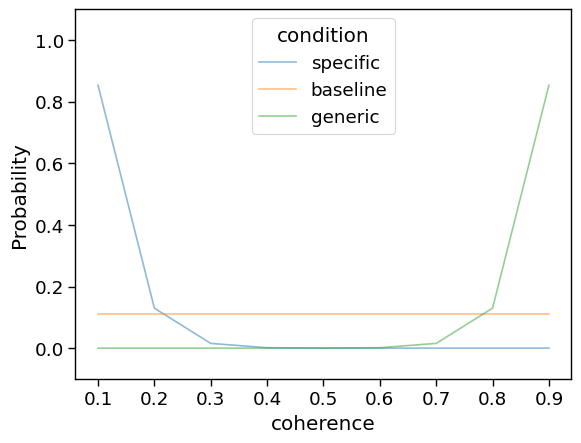

In [17]:
# plot coherence
g = sns.lineplot(data = coherence_condition,
                 hue = "condition", alpha = 0.5, 
                 x = "Element",
                 y = "Probability")
plt.xlabel("coherence")
plt.ylim(-0.1, 1.1)
plt.show(g)

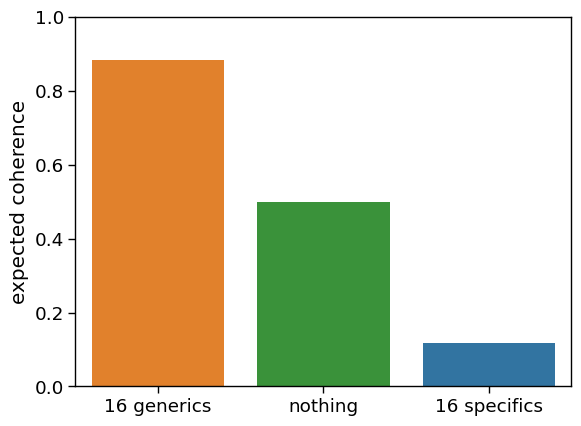

In [18]:
# plot coherence EV
g = sns.barplot(data = coherence_condition_ev,
                x = 'condition', y = 'coherence_ev',
                hue = 'condition', palette = condition_colors)
plt.xlabel("")
plt.xticks(ticks=['generic', 'baseline', 'specific'],
           labels=['16 generics', 'nothing', '16 specifics'])
plt.ylabel("expected coherence")
plt.ylim(0, 1)
plt.savefig("figs/study 6/predictions_coherence.png", bbox_inches = "tight")
plt.show(g)

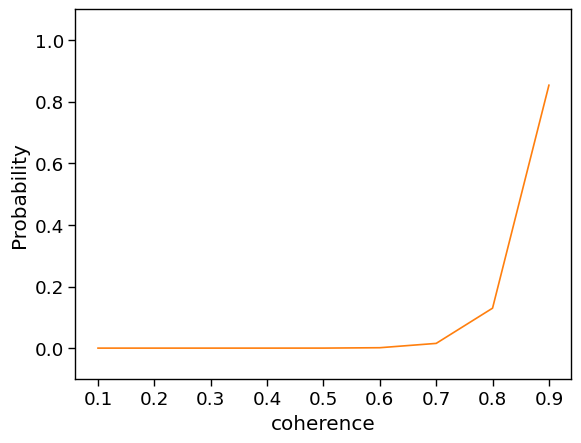

In [19]:
# plot coherence
g = sns.lineplot(data = dist_to_df(dist_coherence_generic_prag),
                 color = condition_colors['generic'],
                 x = "Element",
                 y = "Probability")
plt.xlabel("coherence")
plt.ylim(-0.1, 1.1)

plt.savefig("figs/study 6/predictions_coherence_generic_prag.png", bbox_inches = "tight")
plt.show(g)

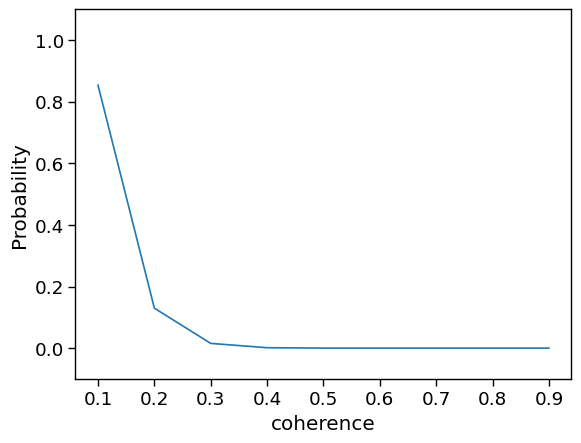

In [20]:
# plot coherence
g = sns.lineplot(data = dist_to_df(dist_coherence_specific_prag),
                 color = condition_colors['specific'],
                 x = "Element",
                 y = "Probability")
plt.xlabel("coherence")
plt.ylim(-0.1, 1.1)

plt.savefig("figs/study 6/predictions_coherence_specific.png", bbox_inches = "tight")
plt.show(g)

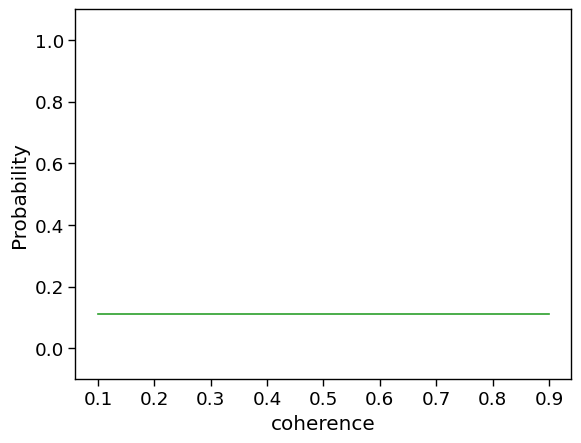

In [21]:
# plot coherence
g = sns.lineplot(data = dist_to_df(dist_coherence_baseline_prag),
                 color = condition_colors['baseline'],
                 x = "Element",
                 y = "Probability")
plt.xlabel("coherence")
plt.ylim(-0.1, 1.1)

plt.savefig("figs/study 6/predictions_coherence_baseline.png", bbox_inches = "tight")
plt.show(g)

**MLE (maximum likelihood estimate)**

find the parameters that maximize the likelihood of the data

$$\theta_{\text{MLE}} = \text{max}_\theta p(d|m,\theta)$$

* $p(d|m,\theta)$ = likelihood

We get the MLE for the following parameters from the data:

* **inverse temperature** (or **speaker rationality**) = how much speaker cares about maximizing utility (`inv_temp`)

* **linking function** to provide prevalence estimates for a novel feature $f'$ after observing a new individual $x$ (member of category $k$) with novel feature $f'$. this link generates a prior about the prevalence of the particular feature, which is a mixture of the following beta distributions:

    * **kind-linked distribution**: probability that the feature has a certain level of prevalence, given that the observed individual with the feature is a kind member, and that the feature is kind-linked. this is a beta distribution with parameters $\alpha$ and $\beta$, which is then weighted by **category coherence** ($\theta$)
        * this distribution is always higher prevalence than the non-generic distribution, since what it means for a feature to be kind-linked is that it predicts higher prevalence
        
    * **non-kind-linked distribution**: probability that the feature has a certain level of prevalence, given that the observed individual with the feature is a kind member, and that the feature is *not* kind-linked. this is a beta distribution with parameters $\alpha$ and $\beta$, which is then weighted by **inverse category coherence** (1 - $\theta$)
        * this distribution can be thought of as the background distribution of prevalence for the feature, for non-category members
        * this distribution is affected by baseline feature-specific beliefs about the prevalence of the feature


$$P(p_{f'}) = P(p_{f'} | x \in k, f' \in F_k) * \theta + P(p_{f'} | x \in k, f' \notin F_k) * (1 - \theta)$$

## Kind-linked vs non-kind-linked prevalence per feature

Linking function linking category coherence to prevalence of a feature

* probability of random kind member $x'$ having novel feature $f'$, given the data = probability of random kind member $x'$ having novel feature $f'$, given a certain kind-linked feature set * probability of that kind-linked feature set given the data, over all possible sets of kind-linked features

$$p(f' \in x' | \overrightarrow{x}, \overrightarrow{u}) = \sum_{F_k} p(f' \in x'|F_k) p(F_k | \overrightarrow{x}, \overrightarrow{u})$$

$$= p(f' \in x'| f' \in F_k) p(f' \in F_k | \overrightarrow{x}, \overrightarrow{u}) + p(f' \in x'| f' \notin F_k) p(f' \notin F_k | \overrightarrow{x}, \overrightarrow{u}) $$

...

* (probability of random kind member $x'$ having novel feature $f'$, if $f'$ is kind-linked) * coherence + (probability of random kind member $x'$ having novel feature $f'$, if $f'$ is *not* kind-linked) * inverse coherence

$$= p(f' \in x'| f' \in F_k) \hat{\theta} + p(f' \in x'| f' \notin F_k) (1-\hat{\theta})$$

* these two terms are the feature's kind-linked prevalence distribution and non-kind-linked prevalence distribution. we fit each of these as a beta distribution

    * $p(f' \in x'| f' \in F_k)$
    * $p(f' \in x'| f' \notin F_k)$

In [22]:
# SAMPLE POINTS FOR PLOTTING

# prevalence points to sample (x-axis)
x = np.linspace(start = 0, stop = 1, num = 1000)

# initialize df to store feature prevalence points
features_prevalence = pd.DataFrame()

# for each feature...
for i, row in mle_per_feature_prag.iterrows():
    # construct beta distributions
    feature_kind_linked_prevalence = Beta(row['feature_kind_linked_prevalence_alpha'], 
                                          row['feature_kind_linked_prevalence_beta'])
    feature_not_kind_linked_prevalence = Beta(row['feature_not_kind_linked_prevalence_alpha'], 
                                              row['feature_not_kind_linked_prevalence_beta'])
    
    # sample points for plotting
    feature_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'kind-linked',
                                                           'prevalence': i, 'probability': feature_kind_linked_prevalence.prob(i)} for i in x])
    feature_not_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'not kind-linked',
                                                               'prevalence': i, 'probability': feature_not_kind_linked_prevalence.prob(i)} for i in x])
    
    # add points to df
    feature_prevalence = pd.concat([feature_kind_linked_prevalence_points, feature_not_kind_linked_prevalence_points], ignore_index=True)
    
    features_prevalence = pd.concat([features_prevalence, feature_prevalence], ignore_index=True)

features_prevalence

/Users/MariannaZhang/Library/CloudStorage/Box-Box/NYU/projects/compgenerics/.venv/lib/python3.13/site-packages/gorgo/distributions/builtin_dists.py:348: RuntimeWarning: divide by zero encountered in scalar power
  num = (element**(self.a - 1))*(1 - element)**(self.b - 1)


,feature,distribution,prevalence,probability
0,live_caves,kind-linked,0.000000,inf
1,live_caves,kind-linked,0.001001,7.721409
2,live_caves,kind-linked,0.002002,5.675042
3,live_caves,kind-linked,0.003003,4.740548
4,live_caves,kind-linked,0.004004,4.172983
...,...,...,...,...
31995,paint_hands,not kind-linked,0.995996,0.000354
31996,paint_hands,not kind-linked,0.996997,0.000231
31997,paint_hands,not kind-linked,0.997998,0.000127
31998,paint_hands,not kind-linked,0.998999,0.000045


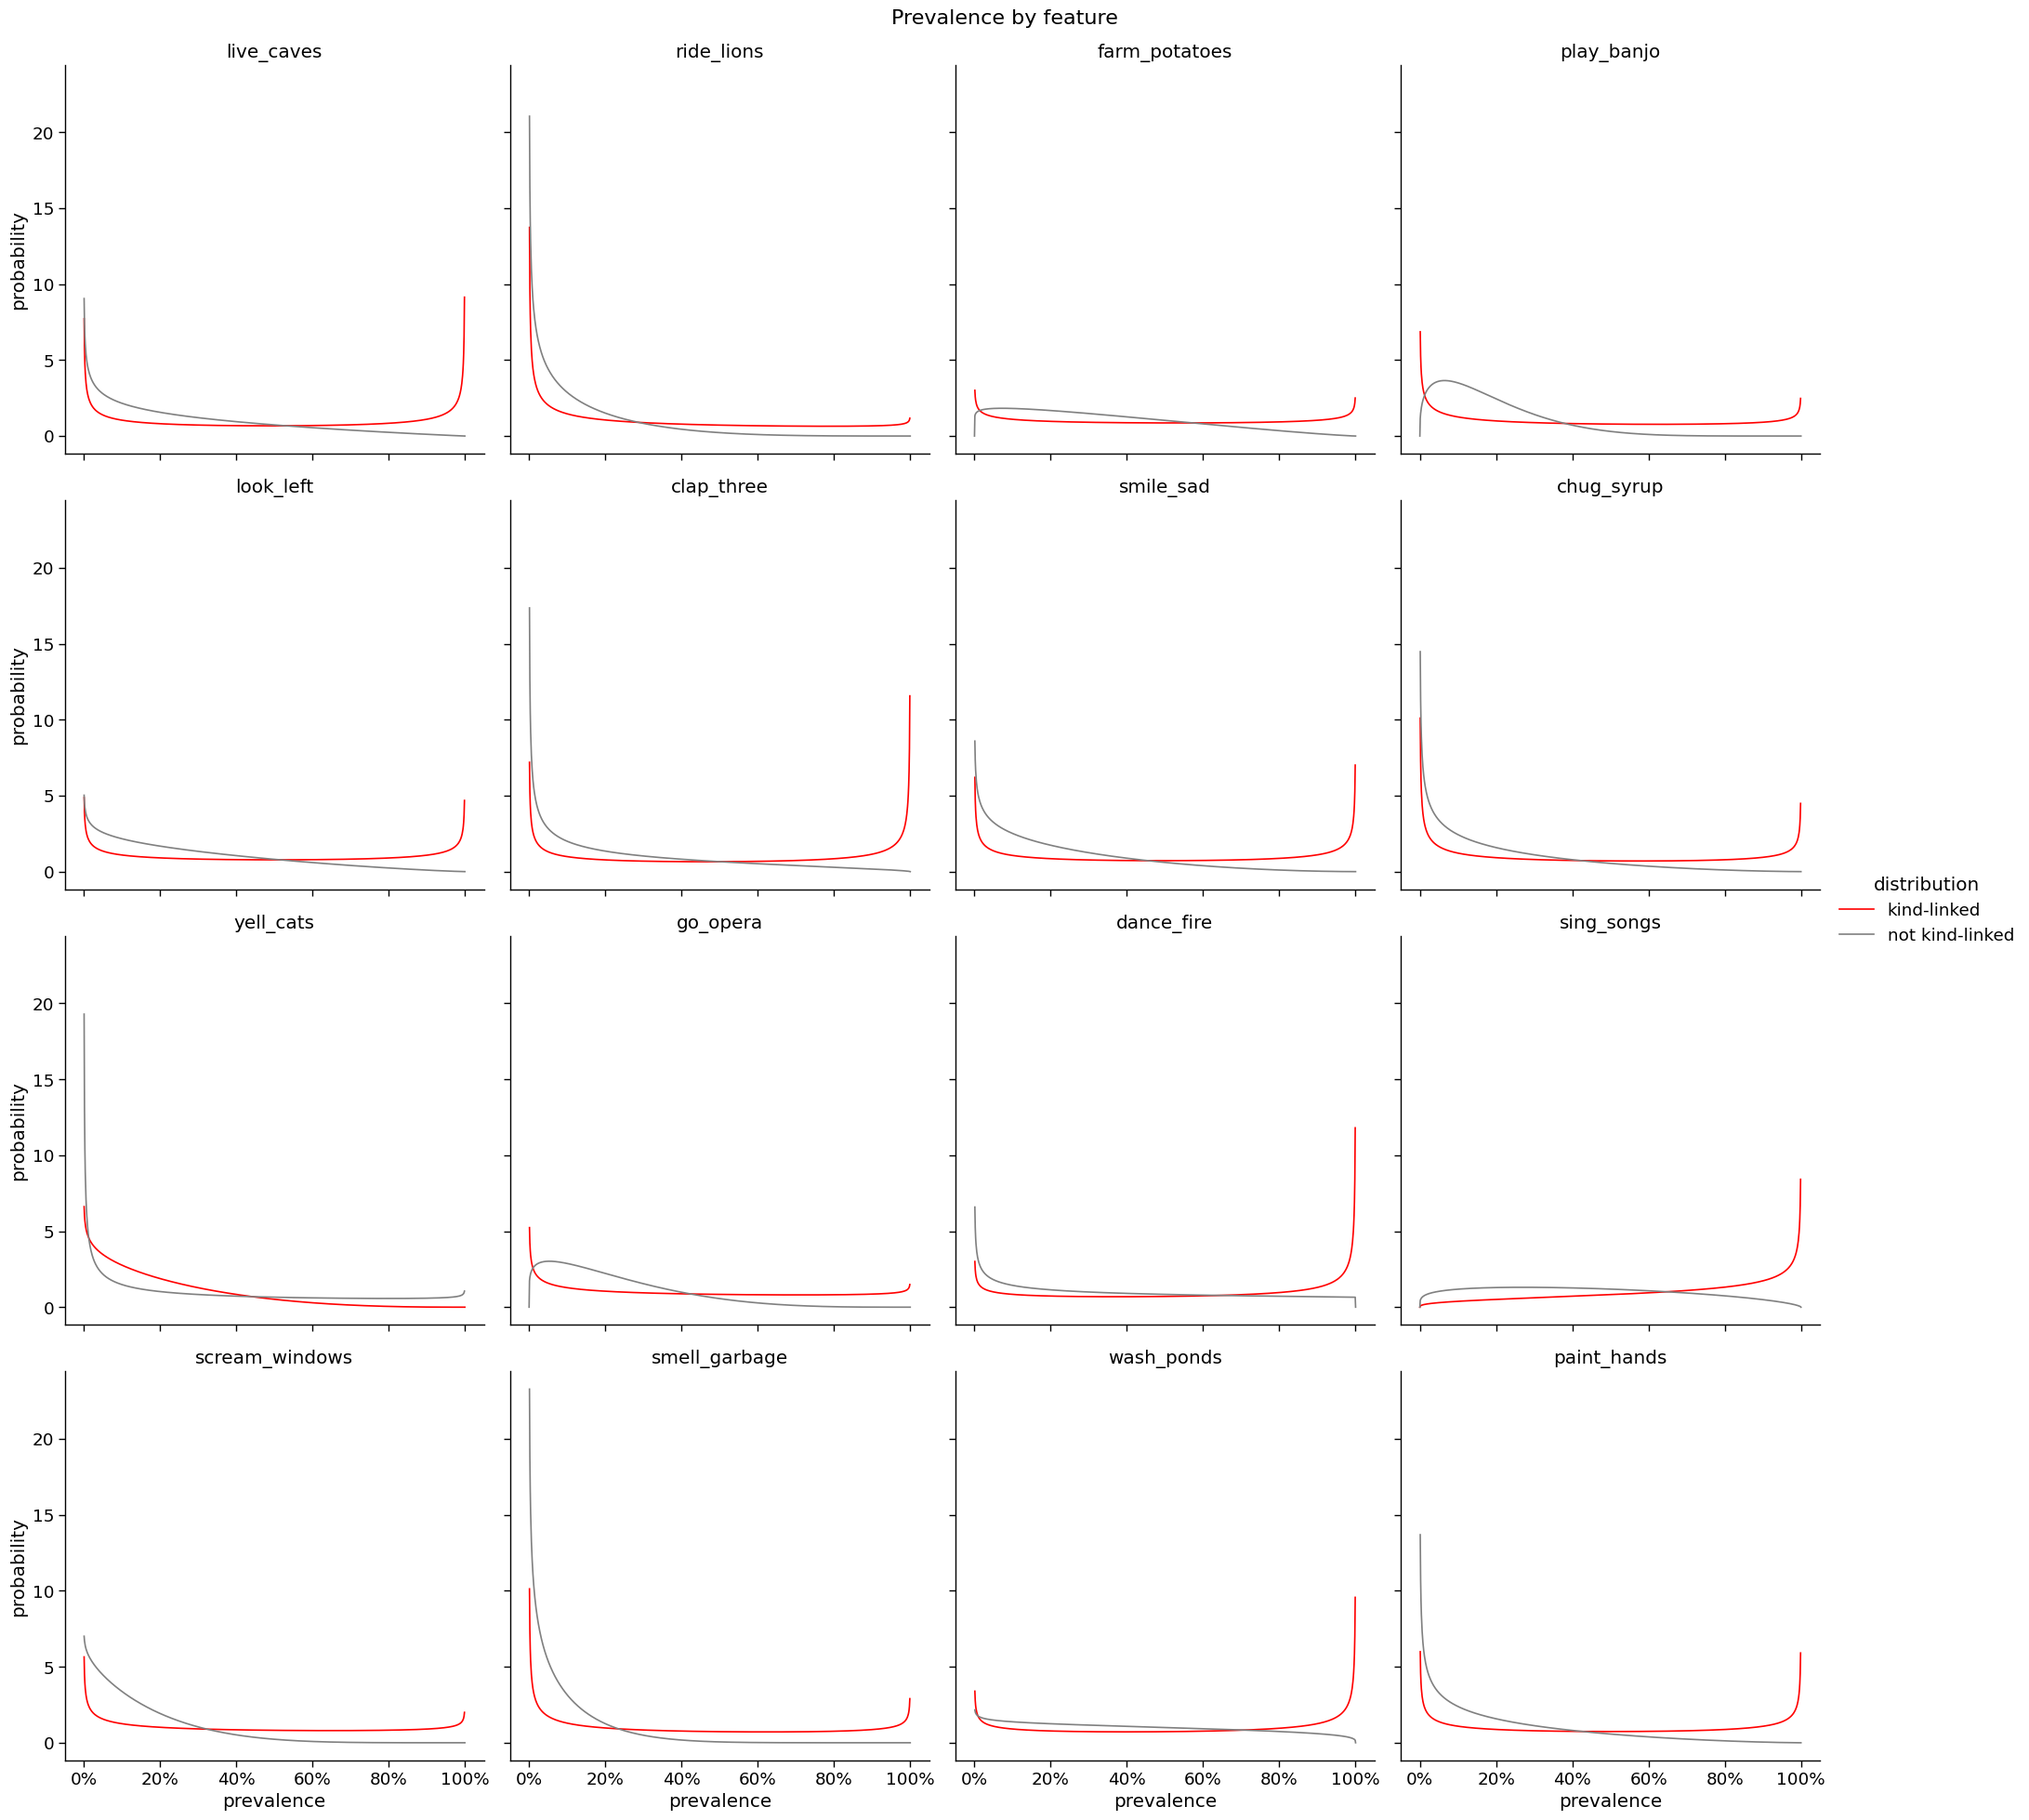

In [23]:
# make plot
g = sns.relplot(data=features_prevalence, 
            x="prevalence", y="probability",
            hue="distribution", palette=["red", "gray"],
            col="feature", col_wrap=4,
            kind="line")
g.fig.suptitle('Prevalence by feature', fontsize=16)
# g.set_titles(col_template=feature_labels) # FIXME
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.95)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.savefig("figs/study 6/prevalence_by_feature.png", bbox_inches = "tight")

## Prevalence predictions

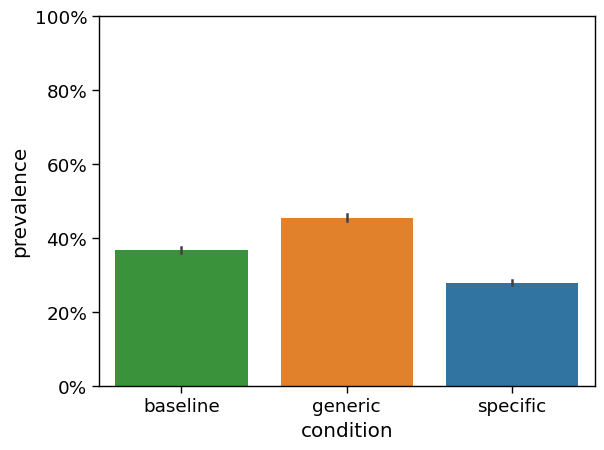

In [24]:
# plot simulated data
g = sns.barplot(df_prag_feature, 
                x="condition", y="prevalence", 
                hue="condition",
                palette=condition_colors,
                legend=False)
# y-axis percentage 0-1
plt.ylim(0, 1)
g.yaxis.set_major_formatter(PercentFormatter(1))

plt.savefig("figs/study 6/prag_prevalence_by_condition.png", bbox_inches = "tight")

/var/folders/5p/8m9jqqdd581dvm8wc358jtz40000gp/T/ipykernel_72574/1873058457.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])


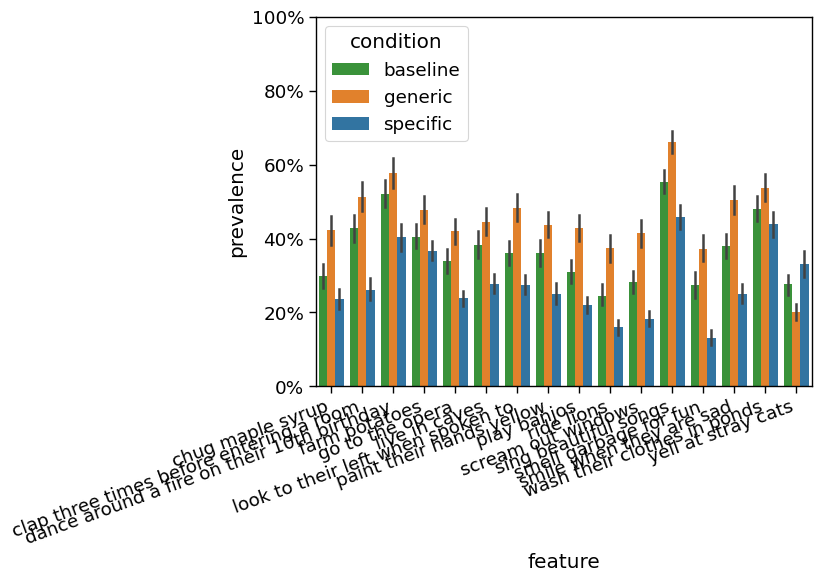

In [25]:
# plot simulated data
g = sns.barplot(df_prag_feature, 
                x="feature", y="prevalence", 
                hue="condition", palette=condition_colors)
# y-axis percentage 0-1
plt.ylim(0, 1)
g.yaxis.set_major_formatter(PercentFormatter(1))
# x-axis rotated long labels
g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])
plt.xticks(rotation=20, ha='right')

plt.savefig("figs/study 6/prag_prevalence_by_feature_condition.png", bbox_inches = "tight")

## Prevalence predictions vs data

In [26]:
# get model, data means for each condition and feature
df_prag_feature_means = df_prag_feature.groupby(['condition', 'feature'], observed=True)['prevalence'].agg('mean').reset_index()

# get model means for each condition
df_prag_means = df_prag_feature.groupby(['condition'], observed=True)['prevalence'].agg('mean').reset_index()

In [27]:
# add source column
df_prag_vs_data = pd.concat([df_tidy_feature_means.assign(source='real_mean'),
                             df_prag_feature_means.assign(source='simulated_mean')])

# pivot to wide, order condition
df_prag_vs_data = df_prag_vs_data.pivot(
    index=['condition', 'feature'],
    columns='source', values='prevalence').reset_index()

# get means per condition
df_prag_vs_data_condition_means = df_prag_vs_data.groupby('condition').agg({
    'real_mean': 'mean',
    'simulated_mean': 'mean'
}).reset_index()

In [28]:
# calculate r^2
r2_prag = {'r': pearsonr(df_prag_vs_data["real_mean"], df_prag_vs_data["simulated_mean"]).statistic,
      'pvalue': pearsonr(df_prag_vs_data["real_mean"], df_prag_vs_data["simulated_mean"]).pvalue}
r2_prag['r2'] = r2_prag['r']**2
r2_prag

# calculate r^2 by condition
r2_prag_by_condition = []

for condition in ["generic", "baseline", "specific"]:
    df = df_prag_vs_data[df_prag_vs_data['condition'] == condition]
    r2_prag_by_condition.append({'condition': condition,
                            'r': pearsonr(df["real_mean"], df["simulated_mean"]).statistic,
                            'pvalue': pearsonr(df["real_mean"], df["simulated_mean"]).pvalue})

r2_prag_by_condition = pd.DataFrame(r2_prag_by_condition)
r2_prag_by_condition['r2'] = r2_prag_by_condition['r']**2
r2_prag_by_condition

,condition,r,pvalue,r2
0,generic,0.852009,0.000028,0.725919
1,baseline,0.859370,0.000020,0.738517
2,specific,0.876470,0.000008,0.768200


### Blank

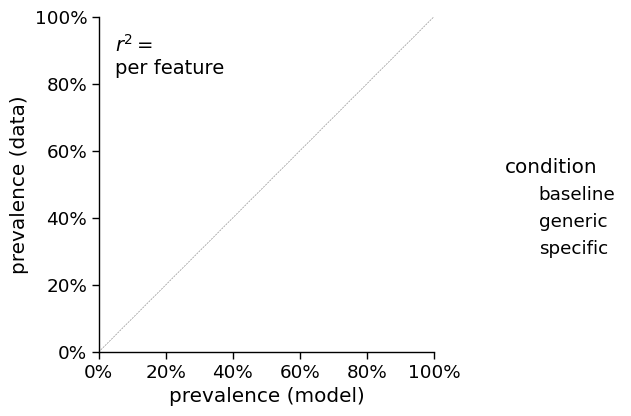

In [29]:
# plot simulated vs real data
g = sns.relplot(df_prag_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=0, zorder=10)

# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')

# r^2 per feature
plt.text(.05, .95, 
         f"$r^2 = $ \nper feature",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)

# footnote
# plt.annotate("small dots: feature means within conditions \nlarge dots: condition means",
#              xy=(0, 0), xytext=(200, -40),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/model_vs_data_by_condition_blank.png", bbox_inches = "tight")


### Per condition

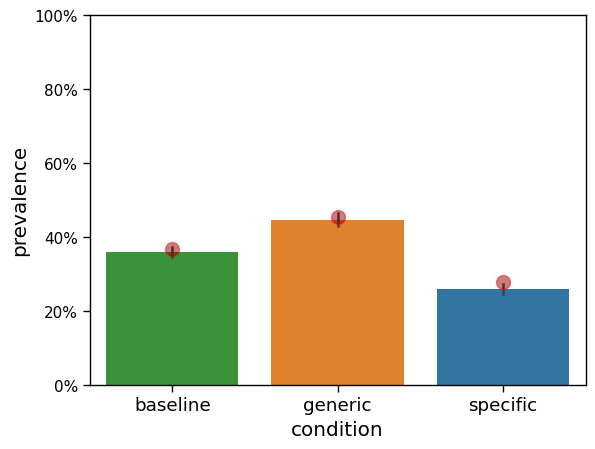

In [30]:
# plot data vs simulated means
plt.figure()

# simulated means
sns.swarmplot(data = df_prag_means, 
                x = 'condition', 
                y = 'prevalence',
                color = 'darkred', alpha = 0.5, size = 10,
                edgecolor = 'red', linewidth = 1,
                zorder=100)

# data
sns.barplot(data = df_tidy,
            x = 'condition', 
            y = 'prevalence',
            hue = 'condition', palette = condition_colors, legend=False)

# y-axis percentage 0-1
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.gca().yaxis.set_tick_params(labelsize = 11)

# footnote
# plt.annotate("dots are simulated means from the fitted model; \nbars are participant means and 95% CIs",
#              xy=(0, 0), xytext=(100, -50),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/data_w_prag_means.png", bbox_inches = "tight")
plt.show(g)


In [31]:
# get simulated and real means with confidence intervals
df_prag_vs_data_means = pd.concat([
    # get data means and 95% confidence intervals
    df_tidy.groupby('condition')
           .agg({'prevalence': ['mean', 'std', 'count']})
           .reset_index()
           .assign(source='data')
           .pipe(lambda x: x.assign(
               ci=1.96 * x[('prevalence','std')] / np.sqrt(x[('prevalence','count')])
           )),
    # get simulated means
    df_prag_feature.groupby('condition')
            .agg({'prevalence': ['mean', 'std', 'count']})
            .reset_index()
            .assign(source='model')
            .pipe(lambda x: x.assign(
                ci=0
           )),
])

# flatten multi-level column names
if isinstance(df_prag_vs_data_means.columns, pd.MultiIndex):
    df_prag_vs_data_means.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] 
                                         for col in df_prag_vs_data_means.columns]

In [32]:
df_prag_vs_data_means

,condition,prevalence_mean,prevalence_std,prevalence_count,source,ci
0,baseline,0.360398,0.289266,1584,data,0.014245
1,generic,0.445605,0.347958,1520,data,0.017493
2,specific,0.260083,0.261510,1440,data,0.013507
0,baseline,0.368460,0.310589,4800,model,0.000000
1,generic,0.454471,0.330007,4800,model,0.000000
2,specific,0.279723,0.260333,4800,model,0.000000


<Figure size 600x500 with 0 Axes>

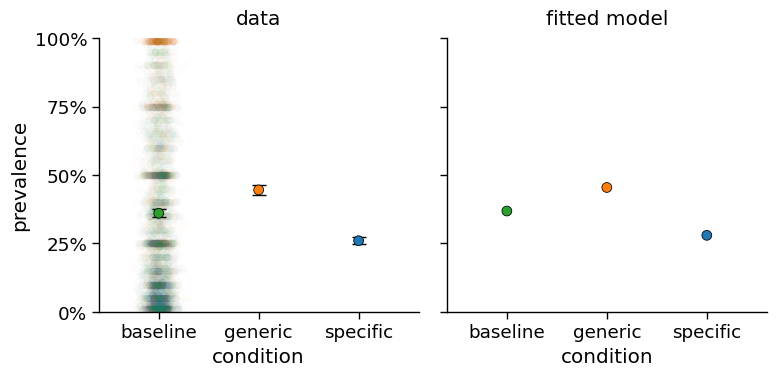

In [33]:
# create faceted plot
plt.figure(figsize=(6, 5))

# create subplot with two facets
g = sns.FacetGrid(df_prag_vs_data_means, 
                  col='source', 
                  height=4, aspect=1)

# draw means and CIs
def plot_with_ci(data, **kwargs):
    # for data only, draw individual data points and CIs
    if data.source.iloc[0] == 'data':
        for condition in condition_colors:
            condition_data = df_tidy[df_tidy['condition'] == condition]
            plt.scatter(x = np.random.normal(pd.Categorical(condition_data['condition']).codes, 
                                            scale=0.08),  # add horizontal jitter 
                        y = condition_data['prevalence'],
                        color = condition_colors[condition], 
                        alpha = 0.01)
        for idx, row in data.iterrows():
            plt.errorbar(x = row.condition, 
                        y = row.prevalence_mean,
                        yerr = row.ci,
                        fmt = 'none', 
                        color = 'black',
                        # color = condition_colors[row.condition], 
                        capsize = 5)

    # draw means
    sns.scatterplot(data = data,
                    x = 'condition', 
                    y = 'prevalence_mean',
                    edgecolor = 'black',
                    hue = 'condition', 
                    palette = condition_colors,
                    s = 50, # size
                    zorder = 100) # draw last

g.map_dataframe(plot_with_ci)

# custom axes, facet titles
for ax, title in zip(g.axes.flat, ['data', 'fitted model']):
    ax.set_title(title, pad = 10) # set facet title, with padding
    ax.set_ylabel('prevalence')
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 1)
    ax.yaxis.set_ticks([0, 0.25, 0.5, 0.75, 1.0]) # labeled points on scale
    ax.margins(x=0.3) # adjust spacing between x-axis

# adjust layout and save
plt.tight_layout()
plt.savefig("figs/study 6/data_vs_prag_means.png", bbox_inches="tight")
plt.show()

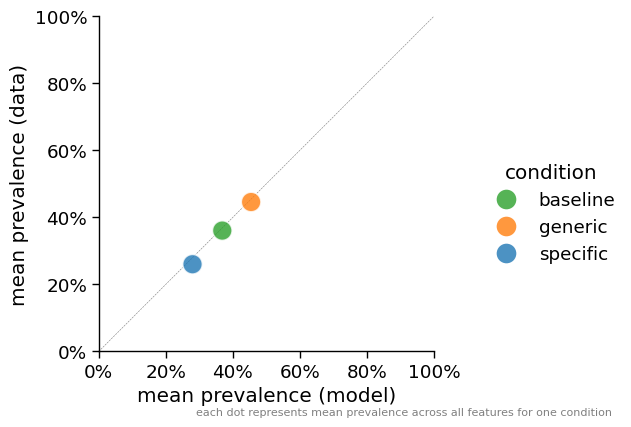

In [34]:
# Plot collapsed data
g = sns.relplot(df_prag_vs_data_condition_means, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors,
                kind='scatter', aspect=1,
                alpha=0.8, zorder=10,
                s=200)  # Make points bigger since there are only 3

# y-axis percentage 0-1
plt.ylabel("mean prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("mean prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')

# footnote
plt.annotate("each dot represents mean prevalence across all features for one condition",
             xy=(0, 0), xytext=(70, -40),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

plt.savefig("figs/study 6/prag_vs_data_by_condition.png", 
            bbox_inches="tight")

### Per feature x condition

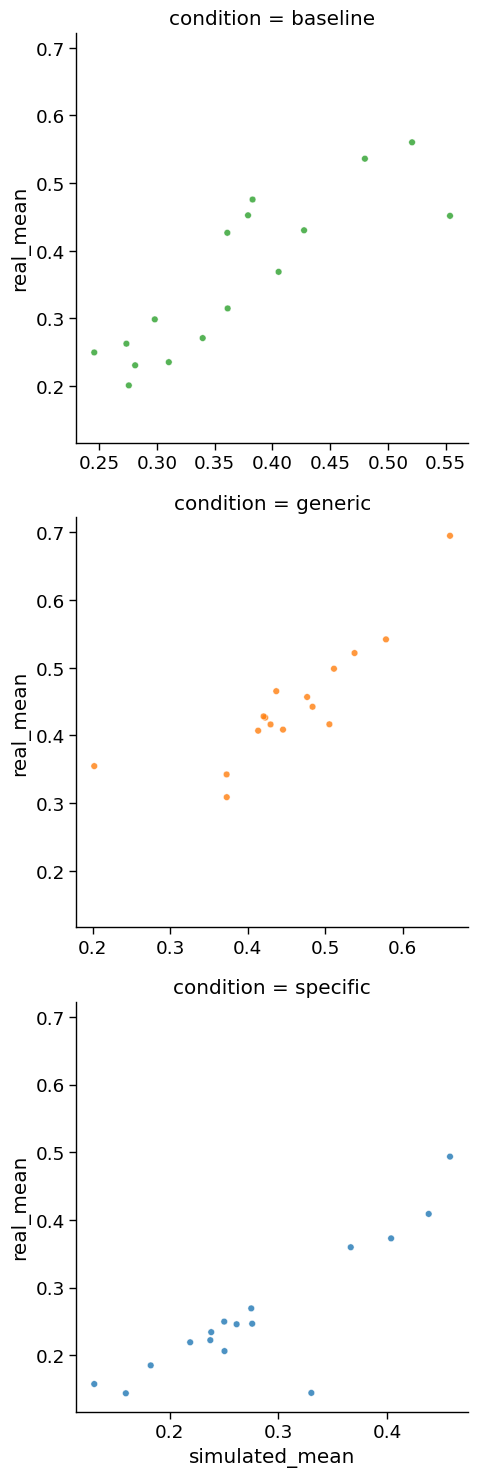

In [35]:
# plot simulated data
g = sns.relplot(df_prag_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, legend=False,
                row='condition', 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10,
                facet_kws={'sharex': False}) # repeat x-axis across facets

plt.savefig("figs/study 6/prag_vs_data_facet_by_condition.png", bbox_inches = "tight")

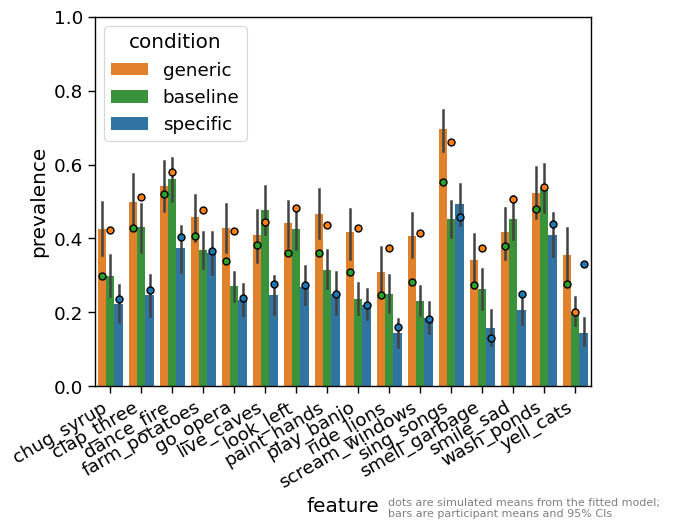

In [36]:
# plot data vs simulated means
plt.figure()

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=300)

# simulated means
sns.stripplot(data = df_prag_feature_means, 
                x = 'feature', 
                y = 'prevalence',
                hue = 'condition', palette = condition_colors, dodge = True, legend = False,
                edgecolor = 'black', linewidth = 1)
                # zorder=10)

# data
sns.barplot(data = df_tidy,
            x = 'feature', order = sorted(df_tidy['feature']), # features in alphabetical order
            y = 'prevalence',
            hue = 'condition', palette = condition_colors)

# y-axis percentage 0-1
plt.ylim(0, 1)
# g.yaxis.set_major_formatter(PercentFormatter(1))
# g.yaxis.set_tick_params(labelsize = 11)
# # x-axis rotated long labels
# g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])
plt.xticks(rotation=30, ha='right')
# g.xaxis.set_tick_params(labelsize = 11)

# footnote
plt.annotate("dots are simulated means from the fitted model; \nbars are participant means and 95% CIs",
             xy=(0, 0), xytext=(200, -80),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

plt.savefig("figs/study 6/data_feature_by_condition_w_prag_means.png", bbox_inches = "tight")
plt.show(g)

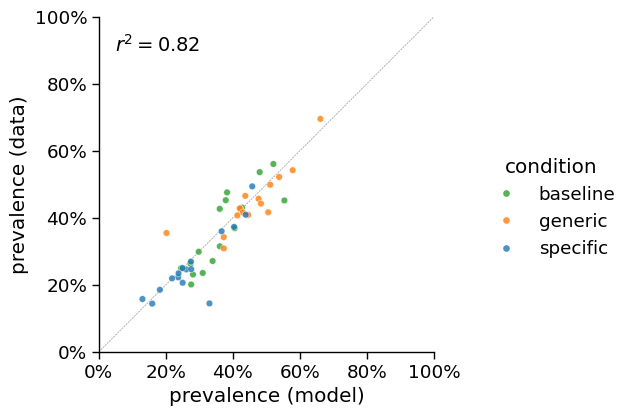

In [37]:
# plot simulated vs real data
g = sns.relplot(df_prag_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10)
# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')
# r^2
plt.text(.05, .95, 
         f"$r^2 = {r2_prag['r2']:.2f}$",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)
# # footnote
# plt.annotate("each dot is a feature within each condition",
#              xy=(0, 0), xytext=(200, -40),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/prag_vs_data_by_condition_feature.png", bbox_inches = "tight")

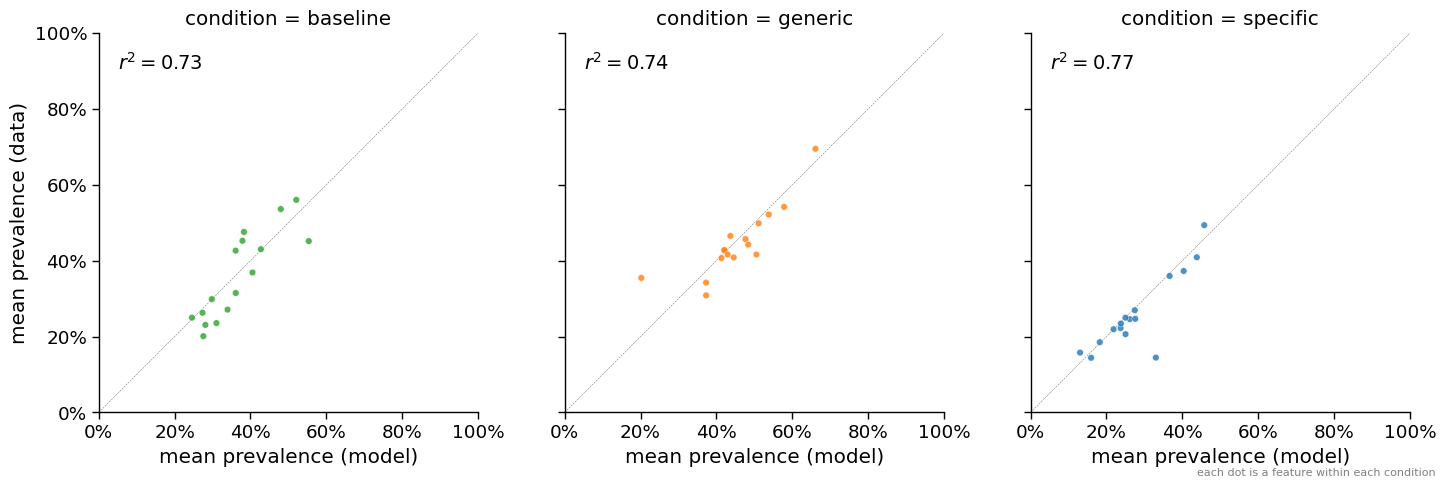

In [38]:
# plot simulated data
g = sns.relplot(df_prag_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, legend=False,
                col='condition', 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10,
                facet_kws={'sharex': False}) # repeat x-axis across facets
# per facet
for ax in g.fig.axes:
    # square ratio
    ax.set_aspect('equal')
    # y-axis
    ax.set_ylabel("mean prevalence (data)")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    # x-axis
    ax.set_xlabel("mean prevalence (model)")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
# x=y lines
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
# r^2
for ax, annotation in zip(g.axes.flat, r2_prag_by_condition['r2']):
    ax.text(.05, .95, 
            f"$r^2 = {annotation:.2f}$", 
            horizontalalignment='left',
            verticalalignment='top',
            fontsize=14)
# footnote
plt.annotate("each dot is a feature within each condition",
             xy=(0, 0), xytext=(120, -40),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

plt.savefig("figs/study 6/prag_vs_data_feature_faceted_by_condition.png", bbox_inches = "tight")

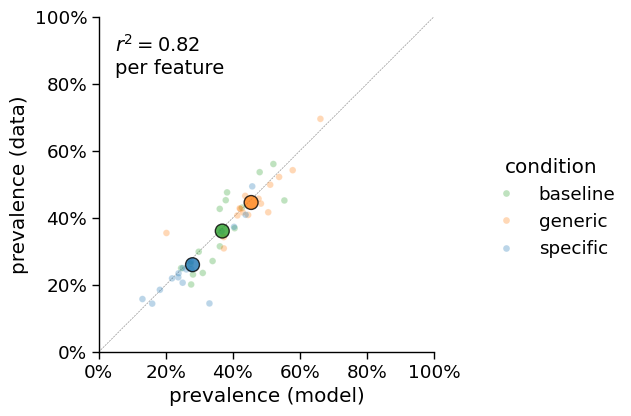

In [39]:
# plot simulated vs real data
g = sns.relplot(df_prag_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.3, zorder=10)

# add condition means as larger points
g.ax.scatter(df_prag_vs_data_condition_means['simulated_mean'],
            df_prag_vs_data_condition_means['real_mean'],
            c=[condition_colors[c] for c in df_prag_vs_data_condition_means['condition']],
            s=100, alpha=0.8, zorder=20,  # Larger size, full opacity, plot on top
            edgecolor='black', linewidth=1)

# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')

# r^2 per feature
plt.text(.05, .95, 
         f"$r^2 = {r2_prag['r2']:.2f}$ \nper feature",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)

# # footnote
# plt.annotate("small dots: feature means within conditions \nlarge dots: condition means",
#              xy=(0, 0), xytext=(200, -40),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/prag_vs_data_by_condition_feature_w_means.png", bbox_inches = "tight")


# Literal listener

## Coherence

In [40]:
# get coherence distribution by condition
coherence_condition_lit = pd.DataFrame()

df = dist_to_df(dist_coherence_generic_lit)
df["condition"] = "generic"
coherence_condition_lit = pd.concat([df, coherence_condition_lit], ignore_index = True)

df = dist_to_df(dist_coherence_baseline_lit)
df["condition"] = "baseline"
coherence_condition_lit = pd.concat([df, coherence_condition_lit], ignore_index = True)

df = dist_to_df(dist_coherence_specific_lit)
df["condition"] = "specific"
coherence_condition_lit = pd.concat([df, coherence_condition_lit], ignore_index = True)

# get coherence expected value by condition
coherence_condition_ev_lit = pd.DataFrame({
  'condition': ['generic', 'baseline', 'specific'], 
  'coherence_ev': [dist_coherence_generic_lit.expected_value(), 
                   dist_coherence_baseline_lit.expected_value(), 
                   dist_coherence_specific_lit.expected_value()]
})

## Kind-linked vs non-kind-linked prevalence

In [41]:
# SAMPLE POINTS FOR PLOTTING

# prevalence points to sample (x-axis)
x = np.linspace(start = 0, stop = 1, num = 1000)

# initialize df to store feature prevalence points
features_prevalence_lit = pd.DataFrame()

# for each feature...
for i, row in mle_per_feature_lit.iterrows():
    # construct beta distributions
    feature_kind_linked_prevalence = Beta(row['feature_kind_linked_prevalence_alpha'], 
                                          row['feature_kind_linked_prevalence_beta'])
    feature_not_kind_linked_prevalence = Beta(row['feature_not_kind_linked_prevalence_alpha'], 
                                              row['feature_not_kind_linked_prevalence_beta'])
    
    # sample points for plotting
    feature_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'kind-linked',
                                                           'prevalence': i, 'probability': feature_kind_linked_prevalence.prob(i)} for i in x])
    feature_not_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'not kind-linked',
                                                               'prevalence': i, 'probability': feature_not_kind_linked_prevalence.prob(i)} for i in x])
    
    # add points to df
    feature_prevalence_lit = pd.concat([feature_kind_linked_prevalence_points, feature_not_kind_linked_prevalence_points], ignore_index=True)

    features_prevalence_lit = pd.concat([features_prevalence_lit, feature_prevalence_lit], ignore_index=True)

features_prevalence_lit

/Users/MariannaZhang/Library/CloudStorage/Box-Box/NYU/projects/compgenerics/.venv/lib/python3.13/site-packages/gorgo/distributions/builtin_dists.py:348: RuntimeWarning: divide by zero encountered in scalar power
  num = (element**(self.a - 1))*(1 - element)**(self.b - 1)


,feature,distribution,prevalence,probability
0,live_caves,kind-linked,0.000000,inf
1,live_caves,kind-linked,0.001001,9.251440e+00
2,live_caves,kind-linked,0.002002,6.699305e+00
3,live_caves,kind-linked,0.003003,5.547614e+00
4,live_caves,kind-linked,0.004004,4.853267e+00
...,...,...,...,...
31995,paint_hands,not kind-linked,0.995996,8.076037e-11
31996,paint_hands,not kind-linked,0.996997,2.260105e-11
31997,paint_hands,not kind-linked,0.997998,3.755399e-12
31998,paint_hands,not kind-linked,0.998999,1.746626e-13


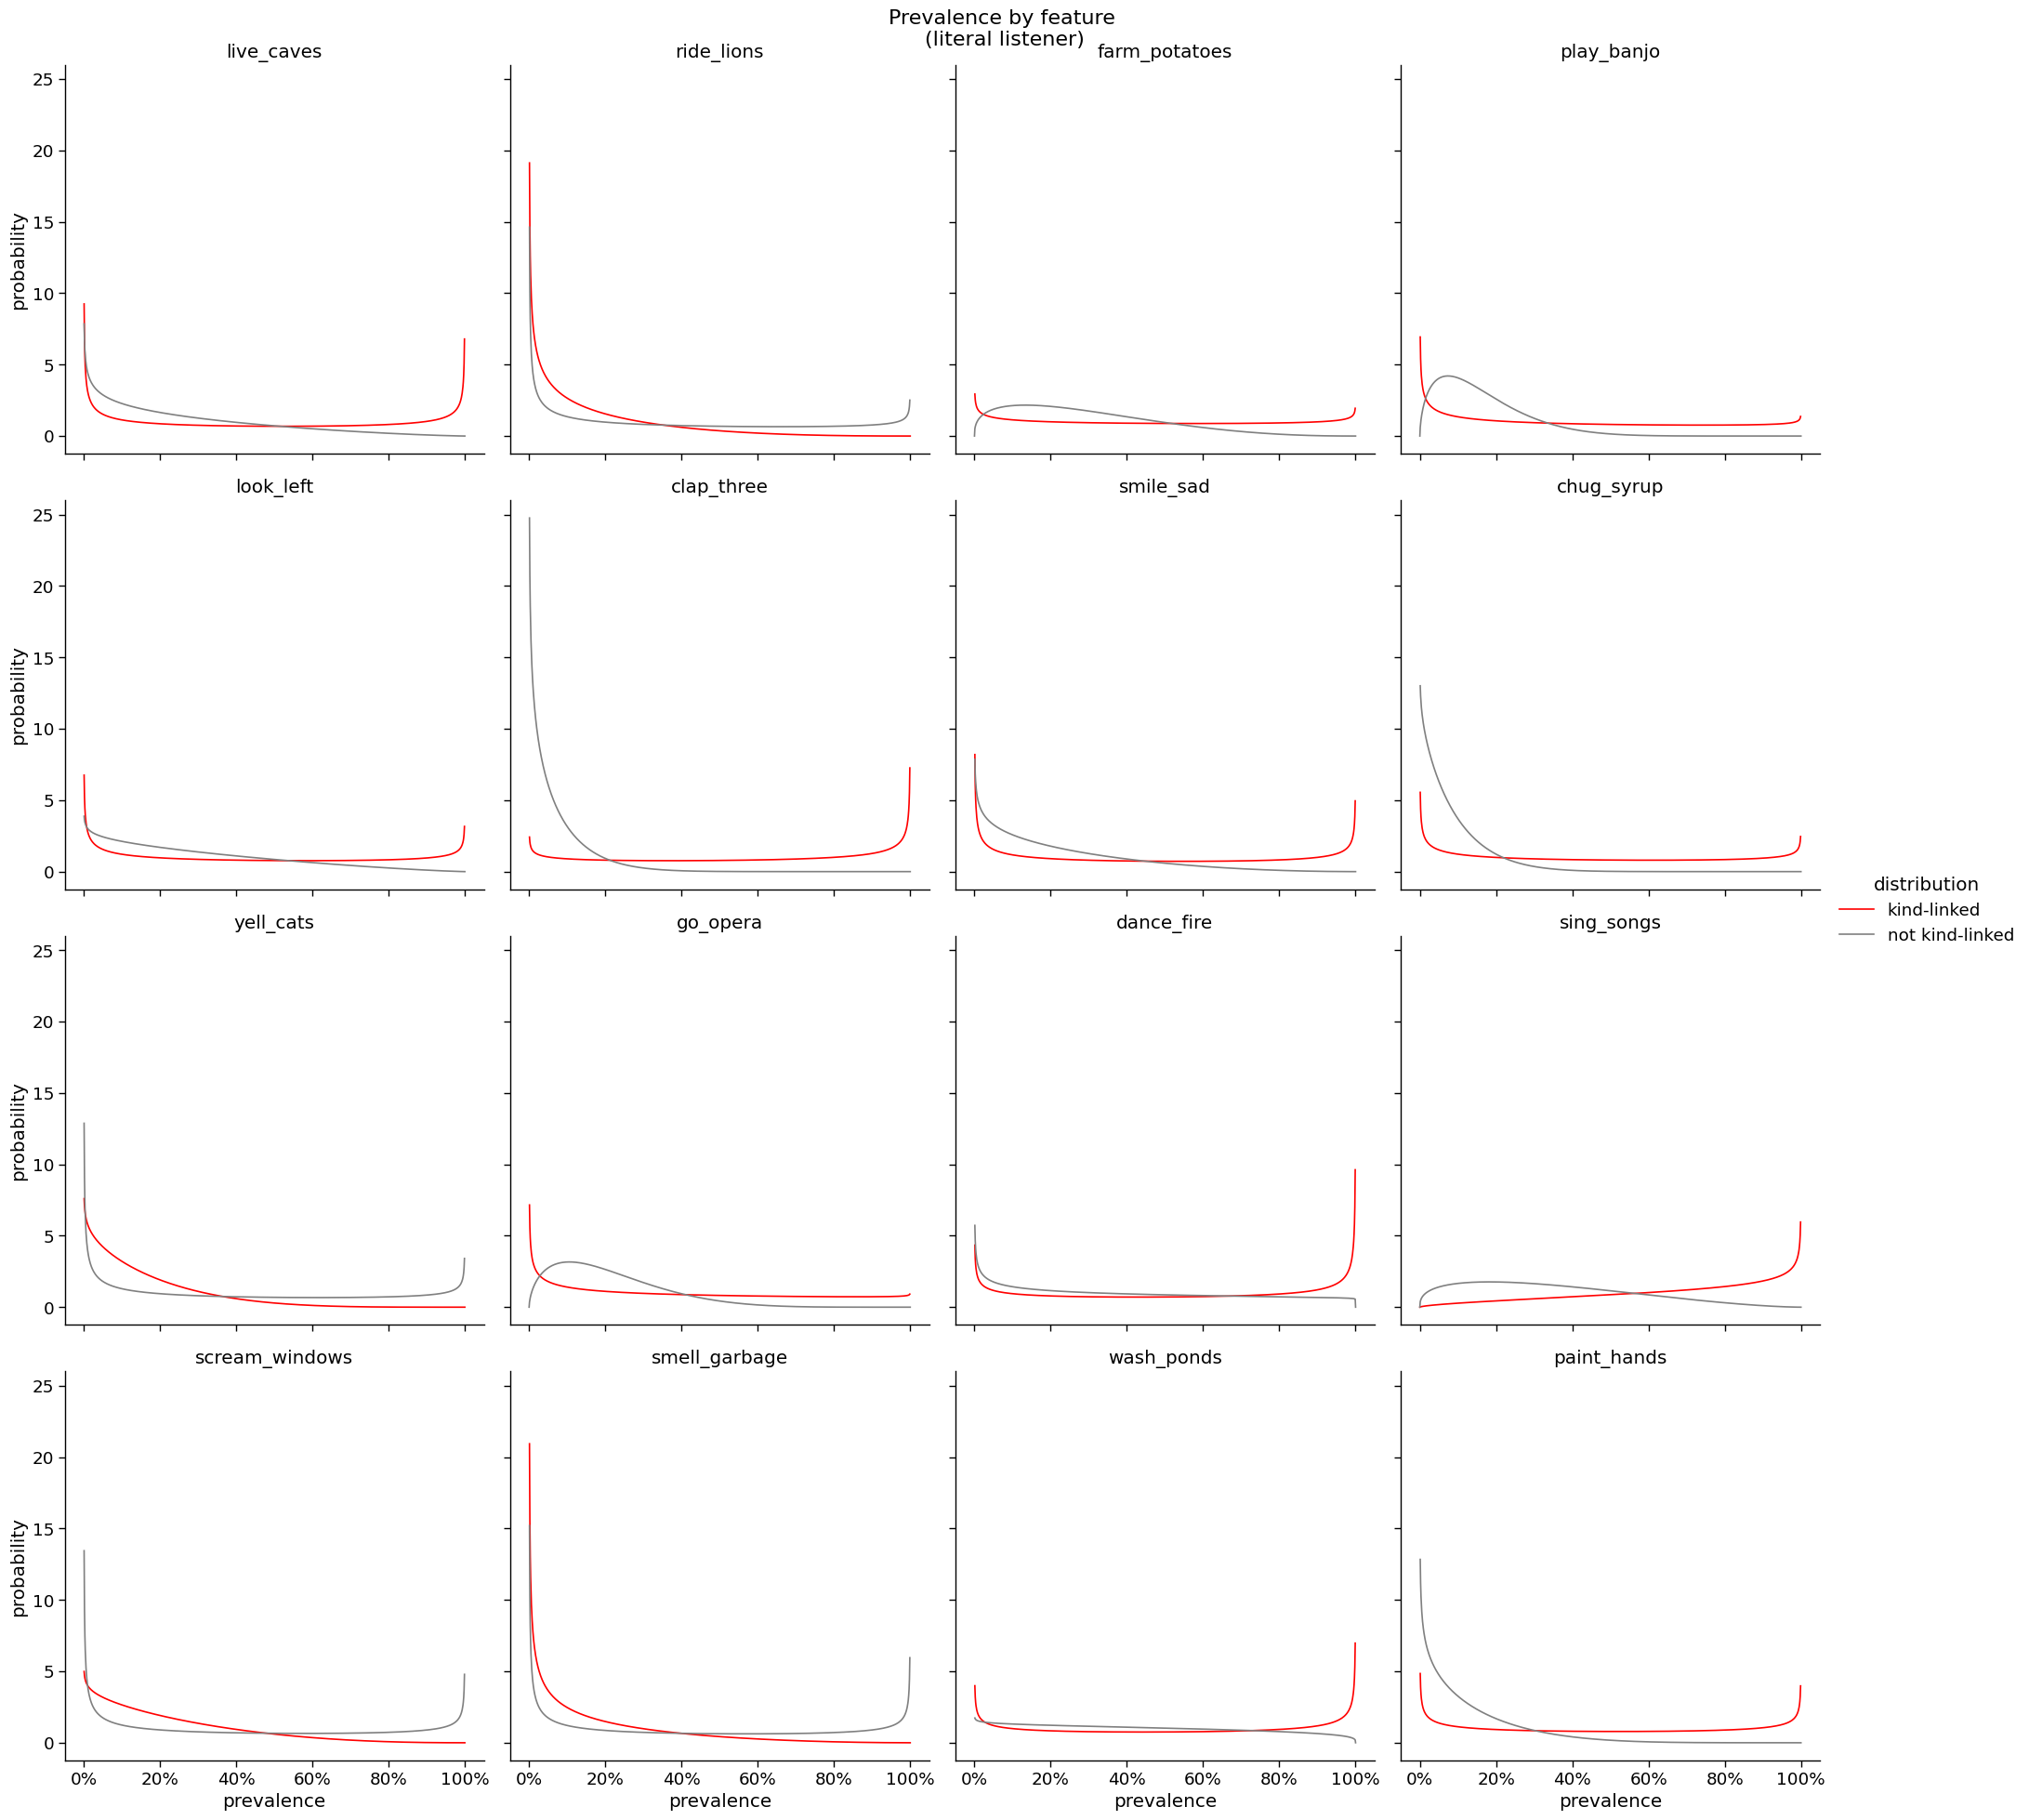

In [42]:
# make plot
g = sns.relplot(data=features_prevalence_lit, 
            x="prevalence", y="probability",
            hue="distribution", palette=["red", "gray"],
            col="feature", col_wrap=4,
            kind="line")
g.fig.suptitle('Prevalence by feature \n(literal listener)', fontsize=16)
# g.set_titles(col_template=feature_labels) # FIXME
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.95)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# plt.savefig("figs/study 6/lit_prevalence_by_feature.png", bbox_inches = "tight")

## Prevalence predictions vs data

In [43]:
# get means for each condition and feature
df_lit_feature_means = df_lit_feature.groupby(['condition', 'feature'], observed=True)['prevalence'].agg('mean').reset_index()

# get means for each condition
df_lit_means = df_lit_feature.groupby(['condition'], observed=True)['prevalence'].agg('mean').reset_index()

In [44]:
# add source column
df_lit_vs_data = pd.concat([df_tidy_feature_means.assign(source='real_mean'),
                            df_lit_feature_means.assign(source='simulated_mean')])

# pivot to wide, order condition
df_lit_vs_data = df_lit_vs_data.pivot(
    index=['condition', 'feature'],
    columns='source', values='prevalence').reset_index()

# get means per condition
df_lit_vs_data_condition_means = df_lit_vs_data.groupby('condition').agg({
    'real_mean': 'mean',
    'simulated_mean': 'mean'
}).reset_index()

In [45]:
# calculate r^2
r2_lit = {'r': pearsonr(df_lit_vs_data["real_mean"], df_lit_vs_data["simulated_mean"]).statistic,
      'pvalue': pearsonr(df_lit_vs_data["real_mean"], df_lit_vs_data["simulated_mean"]).pvalue}
r2_lit['r2'] = r2_lit['r']**2
r2_lit

# calculate r^2 by condition
r2_lit_by_condition = []

for condition in ["generic", "baseline", "specific"]:
    df = df_lit_vs_data[df_lit_vs_data['condition'] == condition]
    r2_lit_by_condition.append({'condition': condition,
                            'r': pearsonr(df["real_mean"], df["simulated_mean"]).statistic,
                            'pvalue': pearsonr(df["real_mean"], df["simulated_mean"]).pvalue})

r2_lit_by_condition = pd.DataFrame(r2_lit_by_condition)
r2_lit_by_condition['r2'] = r2_lit_by_condition['r']**2

In [46]:
r2_lit_by_condition

,condition,r,pvalue,r2
0,generic,0.858543,0.000021,0.737096
1,baseline,0.782817,0.000337,0.612802
2,specific,0.859963,0.000019,0.739537


### Per feature x condition

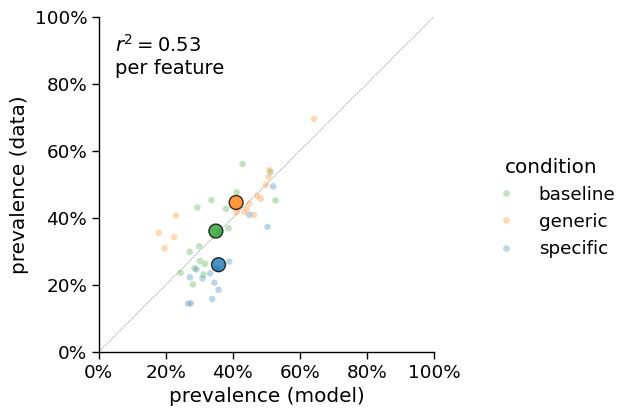

In [47]:
# plot simulated vs real data
g = sns.relplot(df_lit_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.3, zorder=10)

# add condition means as larger points
g.ax.scatter(df_lit_vs_data_condition_means['simulated_mean'],
            df_lit_vs_data_condition_means['real_mean'],
            c=[condition_colors[c] for c in df_lit_vs_data_condition_means['condition']],
            s=100, alpha=0.8, zorder=20,  # Larger size, full opacity, plot on top
            edgecolor='black', linewidth=1)

# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')

# r^2 per feature
plt.text(.05, .95, 
         f"$r^2 = {r2_lit['r2']:.2f}$ \nper feature",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)

# # footnote
# plt.annotate("small dots: feature means within conditions \nlarge dots: condition means",
#              xy=(0, 0), xytext=(200, -50),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/literal_vs_data_by_condition.png", bbox_inches = "tight")


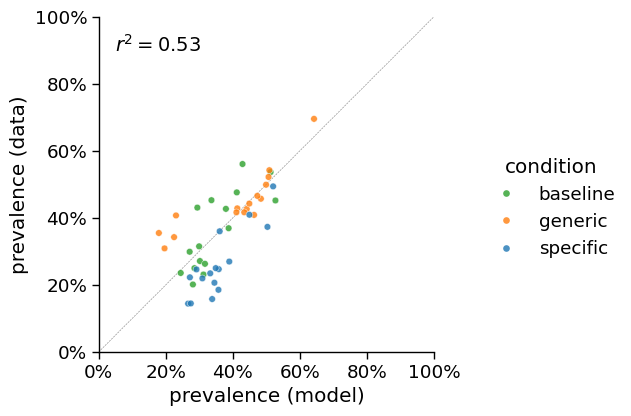

In [48]:
# plot simulated vs real data
g = sns.relplot(df_lit_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10)
# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')
# r^2
plt.text(.05, .95, 
         f"$r^2 = {r2_lit['r2']:.2f}$",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)
# # footnote
# plt.annotate("each dot is a feature within each condition",
#              xy=(0, 0), xytext=(200, -40),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/literal_vs_data_by_condition_feature.png", bbox_inches = "tight")

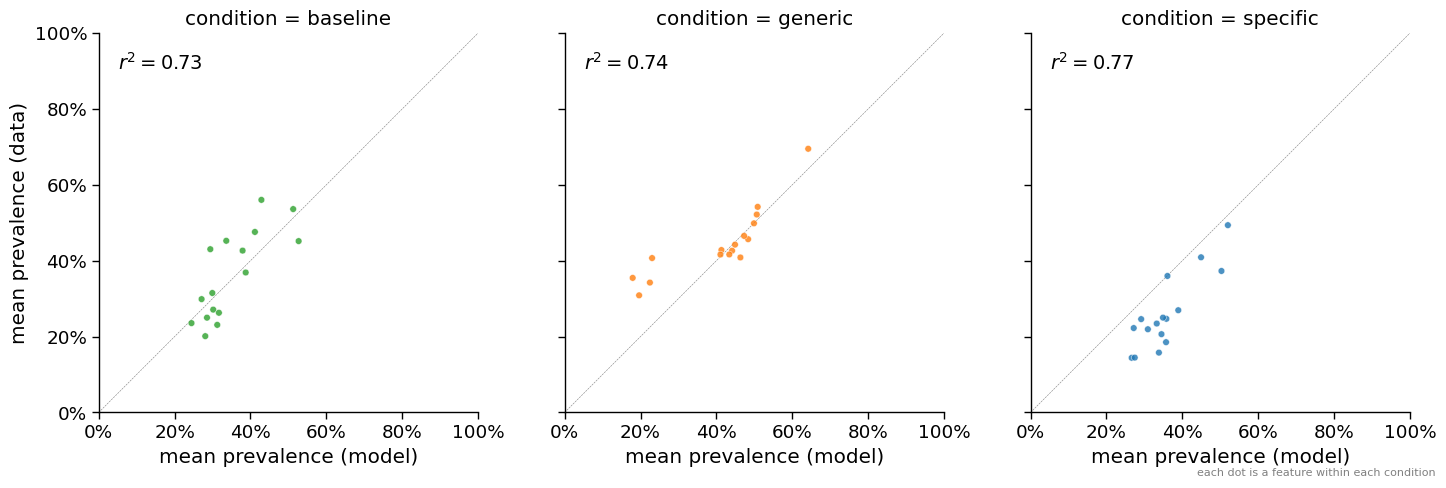

In [49]:
# plot simulated data
g = sns.relplot(df_lit_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, legend=False,
                col='condition', 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10,
                facet_kws={'sharex': False}) # repeat x-axis across facets
# per facet
for ax in g.fig.axes:
    # square ratio
    ax.set_aspect('equal')
    # y-axis
    ax.set_ylabel("mean prevalence (data)")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    # x-axis
    ax.set_xlabel("mean prevalence (model)")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
# x=y lines
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
# r^2
for ax, annotation in zip(g.axes.flat, r2_prag_by_condition['r2']):
    ax.text(.05, .95, 
            f"$r^2 = {annotation:.2f}$", 
            horizontalalignment='left',
            verticalalignment='top',
            fontsize=14)
# footnote
plt.annotate("each dot is a feature within each condition",
             xy=(0, 0), xytext=(120, -40),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

plt.savefig("figs/study 6/lit_vs_data_feature_faceted_by_condition.png", bbox_inches = "tight")

# Base model

## Coherence

In [50]:
# get coherence distribution by condition
coherence_condition_base = pd.DataFrame()

df = dist_to_df(dist_coherence_generic_base)
df["condition"] = "generic"
coherence_condition_base = pd.concat([df, coherence_condition_base], ignore_index = True)

df = dist_to_df(dist_coherence_baseline_base)
df["condition"] = "baseline"
coherence_condition_base = pd.concat([df, coherence_condition_base], ignore_index = True)

df = dist_to_df(dist_coherence_specific_base)
df["condition"] = "specific"
coherence_condition_base = pd.concat([df, coherence_condition_base], ignore_index = True)

coherence_condition_ev_base = pd.DataFrame({
  'condition': ['generic', 'baseline', 'specific'], 
  'coherence_ev': [dist_coherence_generic_base.expected_value(), 
                   dist_coherence_baseline_base.expected_value(), 
                   dist_coherence_specific_base.expected_value()]
})

coherence_condition_base

,Element,Probability,condition
0,0.1,0.111111,specific
1,0.3,0.111111,specific
2,0.7,0.111111,specific
3,0.9,0.111111,specific
4,0.6,0.111111,specific
5,0.8,0.111111,specific
6,0.5,0.111111,specific
7,0.2,0.111111,specific
8,0.4,0.111111,specific
9,0.1,0.111111,baseline


The base model has a uniform posterior over coherence after each condition.

## Kind-linked vs non-kind-linked prevalence

In [51]:
# SAMPLE POINTS FOR PLOTTING

# prevalence points to sample (x-axis)
x = np.linspace(start = 0, stop = 1, num = 1000)

# initialize df to store feature prevalence points
features_prevalence_base = pd.DataFrame()

# for each feature...
for i, row in mle_per_feature_base.iterrows():
    # construct beta distributions
    feature_kind_linked_prevalence = Beta(row['feature_kind_linked_prevalence_alpha'], 
                                          row['feature_kind_linked_prevalence_beta'])
    feature_not_kind_linked_prevalence = Beta(row['feature_not_kind_linked_prevalence_alpha'], 
                                              row['feature_not_kind_linked_prevalence_beta'])
    
    # sample points for plotting
    feature_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'kind-linked',
                                                           'prevalence': i, 'probability': feature_kind_linked_prevalence.prob(i)} for i in x])
    feature_not_kind_linked_prevalence_points = pd.DataFrame([{'feature': row['feature'], 'distribution': 'not kind-linked',
                                                               'prevalence': i, 'probability': feature_not_kind_linked_prevalence.prob(i)} for i in x])
    
    # add points to df
    feature_prevalence_base = pd.concat([feature_kind_linked_prevalence_points, feature_not_kind_linked_prevalence_points], ignore_index=True)
    
    features_prevalence_base = pd.concat([features_prevalence_base, feature_prevalence_base], ignore_index=True)

features_prevalence_base

/Users/MariannaZhang/Library/CloudStorage/Box-Box/NYU/projects/compgenerics/.venv/lib/python3.13/site-packages/gorgo/distributions/builtin_dists.py:348: RuntimeWarning: divide by zero encountered in scalar power
  num = (element**(self.a - 1))*(1 - element)**(self.b - 1)


,feature,distribution,prevalence,probability
0,live_caves,kind-linked,0.000000,inf
1,live_caves,kind-linked,0.001001,10.826172
2,live_caves,kind-linked,0.002002,8.900324
3,live_caves,kind-linked,0.003003,7.931053
4,live_caves,kind-linked,0.004004,7.304370
...,...,...,...,...
31995,paint_hands,not kind-linked,0.995996,3.661196
31996,paint_hands,not kind-linked,0.996997,4.055858
31997,paint_hands,not kind-linked,0.997998,4.685897
31998,paint_hands,not kind-linked,0.998999,5.998991


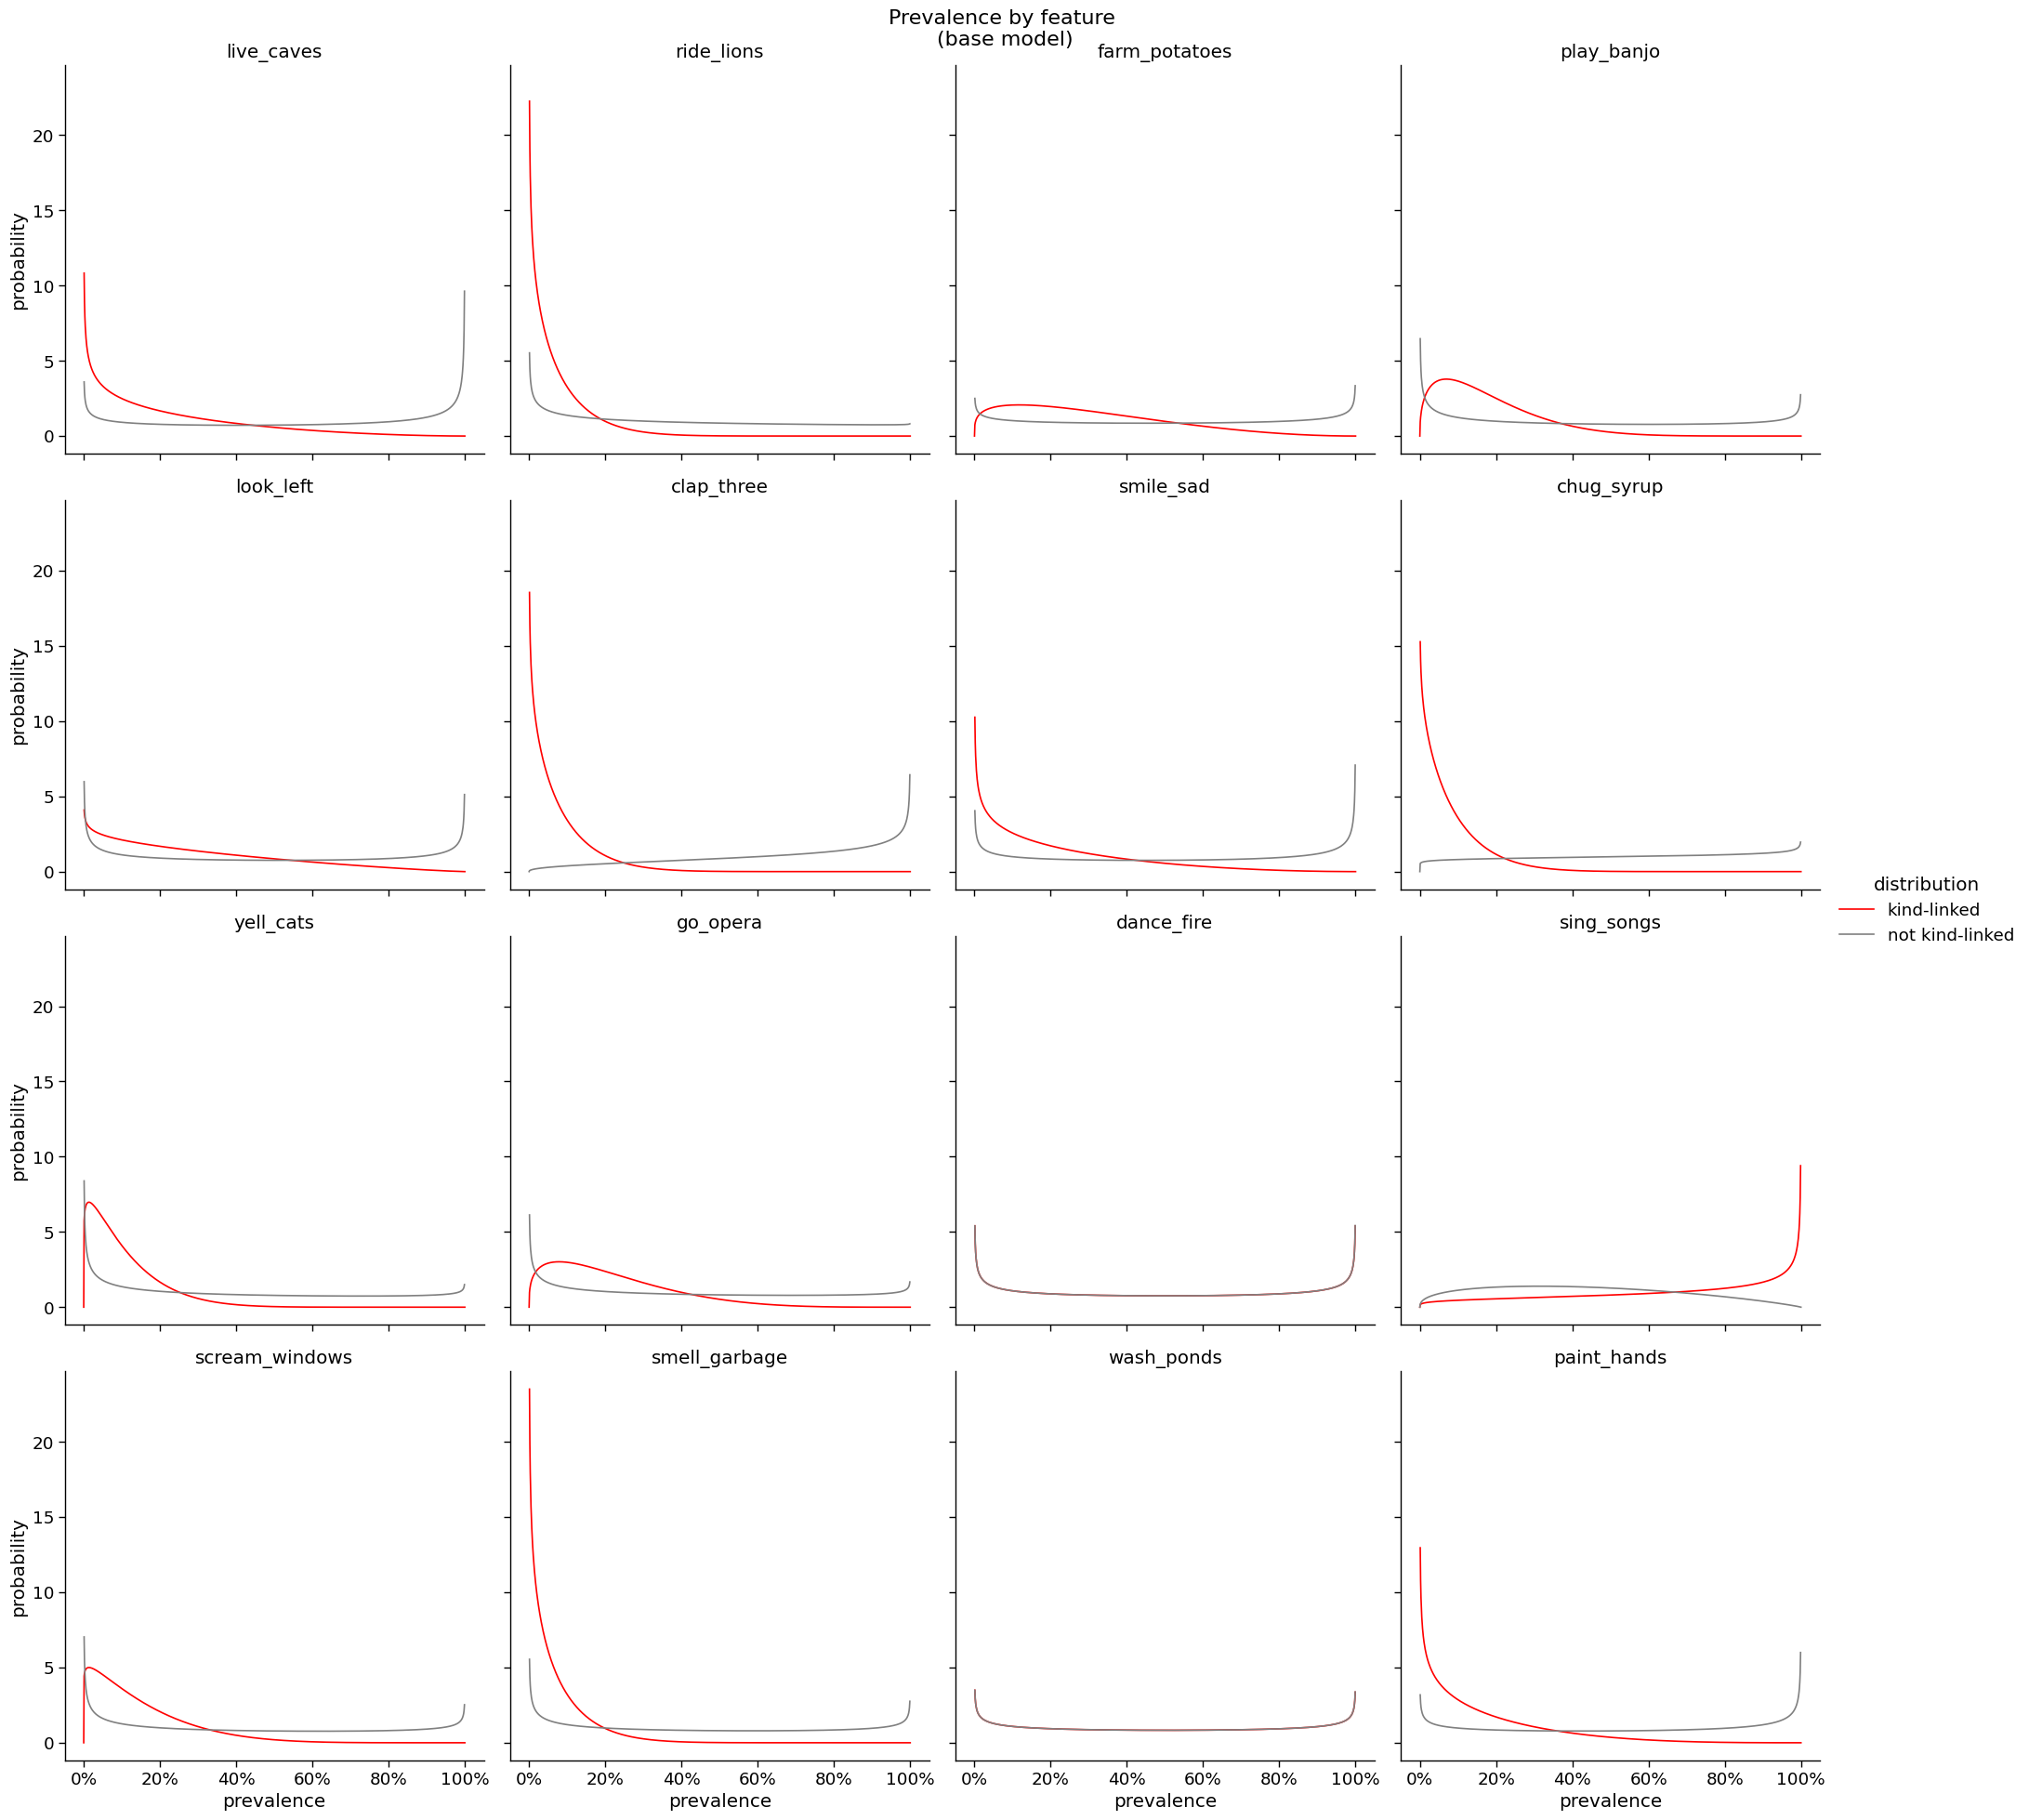

In [52]:
# make plot
g = sns.relplot(data=features_prevalence_base, 
            x="prevalence", y="probability",
            hue="distribution", palette=["red", "gray"],
            col="feature", col_wrap=4,
            kind="line")
g.fig.suptitle('Prevalence by feature \n(base model)', fontsize=16)
# g.set_titles(col_template=feature_labels) # FIXME
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.95)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# plt.savefig("figs/study 6/base_prevalence_by_feature.png", bbox_inches = "tight")

## Prevalence predictions vs data

In [53]:
# get means for each condition and feature
df_base_feature_means = df_base_feature.groupby(['condition', 'feature'], observed=True)['prevalence'].agg('mean').reset_index()

# get means for each condition
df_base_means = df_base_feature.groupby(['condition'], observed=True)['prevalence'].agg('mean').reset_index()

In [54]:
# add source column
df_base_vs_data = pd.concat([df_tidy_feature_means.assign(source='real_mean'),
                             df_base_feature_means.assign(source='simulated_mean')])

# pivot to wide, order condition
df_base_vs_data = df_base_vs_data.pivot(
    index=['condition', 'feature'],
    columns='source', values='prevalence').reset_index()

# get means per condition
df_base_vs_data_condition_means = df_base_vs_data.groupby('condition').agg({
    'real_mean': 'mean',
    'simulated_mean': 'mean'
}).reset_index()

In [55]:
# calculate r^2
r2_base = {'r': pearsonr(df_base_vs_data["real_mean"], df_base_vs_data["simulated_mean"]).statistic,
      'pvalue': pearsonr(df_base_vs_data["real_mean"], df_base_vs_data["simulated_mean"]).pvalue}
r2_base['r2'] = r2_base['r']**2
r2_base

# calculate r^2 by condition
r2_base_by_condition = []

for condition in ["generic", "baseline", "specific"]:
    df = df_base_vs_data[df_base_vs_data['condition'] == condition]
    r2_base_by_condition.append({'condition': condition,
                            'r': pearsonr(df["real_mean"], df["simulated_mean"]).statistic,
                            'pvalue': pearsonr(df["real_mean"], df["simulated_mean"]).pvalue})

r2_base_by_condition = pd.DataFrame(r2_base_by_condition)
r2_base_by_condition['r2'] = r2_base_by_condition['r']**2

In [56]:
r2_base_by_condition

,condition,r,pvalue,r2
0,generic,0.872358,1.049376e-05,0.761008
1,baseline,0.821531,9.510228e-05,0.674913
2,specific,0.951491,1.490276e-08,0.905334


### Per feature x condition

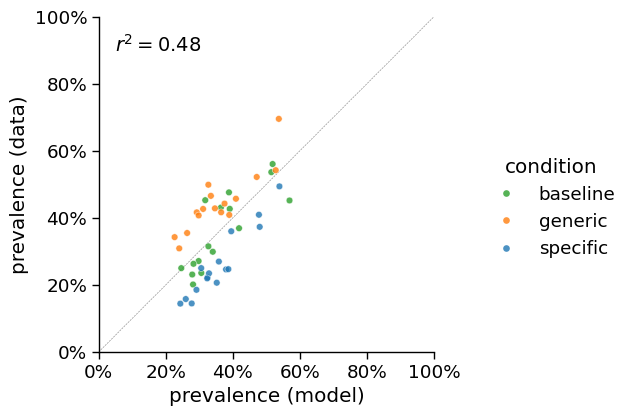

In [57]:
# plot base model vs real data
g = sns.relplot(df_base_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10)
# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')
# r^2
plt.text(.05, .95, 
         f"$r^2 = {r2_base['r2']:.2f}$",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)
# # footnote
# plt.annotate("each dot is a feature within each condition",
#              xy=(0, 0), xytext=(200, -40),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/base_vs_data_by_condition_feature.png", bbox_inches = "tight")

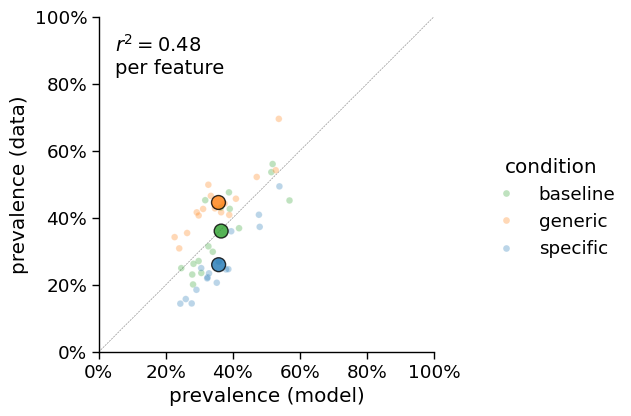

In [58]:
# plot base model vs real data + means

g = sns.relplot(df_base_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, 
                kind='scatter', aspect=1,
                alpha=.3, zorder=10)

# add condition means as larger points
g.ax.scatter(df_base_vs_data_condition_means['simulated_mean'],
            df_base_vs_data_condition_means['real_mean'],
            c=[condition_colors[c] for c in df_base_vs_data_condition_means['condition']],
            s=100, alpha=0.8, zorder=20,  # Larger size, full opacity, plot on top
            edgecolor='black', linewidth=1)

# y-axis percentage 0-1
plt.ylabel("prevalence (data)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# x-axis percentage 0-1
plt.xlabel("prevalence (model)")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
# x=y line, square
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
plt.gca().set_aspect('equal')

# r^2 per feature
plt.text(.05, .95, 
         f"$r^2 = {r2_base['r2']:.2f}$ \nper feature",
         horizontalalignment='left',
         verticalalignment='top',
         fontsize=14)

# # footnote
# plt.annotate("small dots: individual features within conditions \n large dots: condition means",
#              xy=(0, 0), xytext=(200, -50),
#              textcoords='offset points', ha='left', va='top',
#              fontsize=8, color='gray')

plt.savefig("figs/study 6/base_vs_data_by_condition_feature_w_means.png", bbox_inches = "tight")


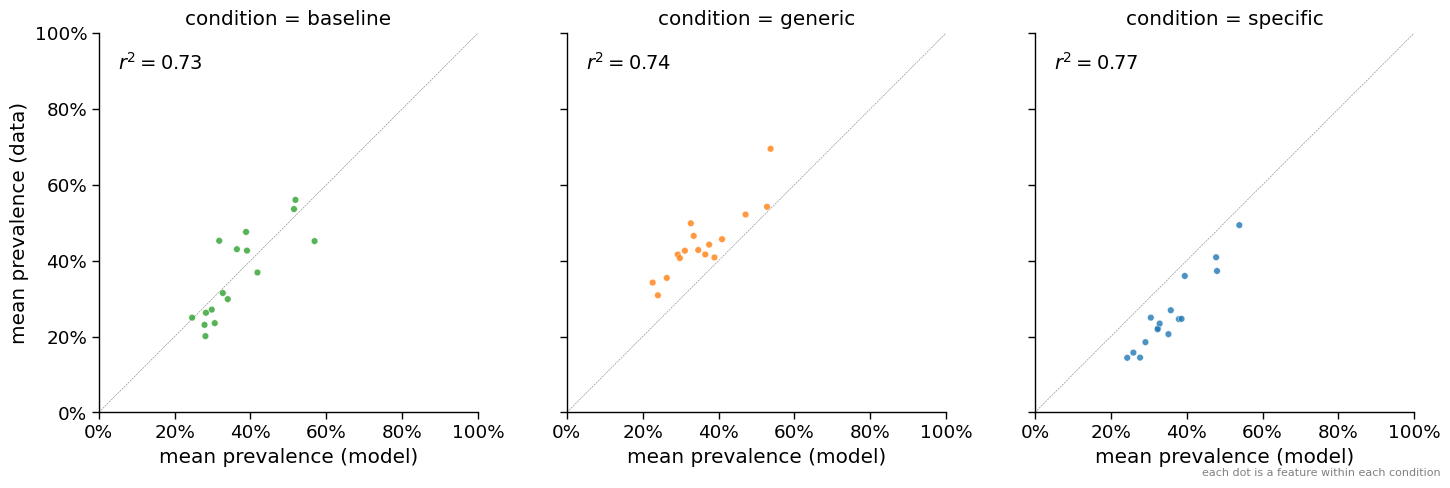

In [59]:
# plot simulated data
g = sns.relplot(df_base_vs_data, 
                x='simulated_mean', y='real_mean',
                hue='condition', palette=condition_colors, legend=False,
                col='condition', 
                kind='scatter', aspect=1,
                alpha=.8, zorder=10,
                facet_kws={'sharex': False}) # repeat x-axis across facets
# per facet
for ax in g.fig.axes:
    # square ratio
    ax.set_aspect('equal')
    # y-axis
    ax.set_ylabel("mean prevalence (data)")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    # x-axis
    ax.set_xlabel("mean prevalence (model)")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
# x=y lines
g.map_dataframe(lambda data, **kws: plt.axline((0, 0), slope=1,
                                               color='gray', linestyle='dashed',
                                               linewidth=.4))
# r^2
for ax, annotation in zip(g.axes.flat, r2_prag_by_condition['r2']):
    ax.text(.05, .95, 
            f"$r^2 = {annotation:.2f}$", 
            horizontalalignment='left',
            verticalalignment='top',
            fontsize=14)
# footnote
plt.annotate("each dot is a feature within each condition",
             xy=(0, 0), xytext=(120, -40),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

plt.savefig("figs/study 6/base_vs_data_feature_faceted_by_condition.png", bbox_inches = "tight")

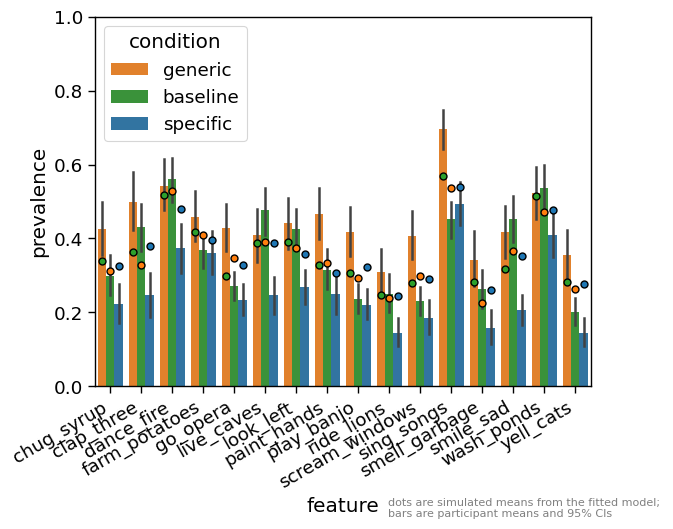

In [60]:
# FIXME: why are model dots in reverse color from bars?


# plot data vs simulated means
plt.figure()

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=300)

# simulated means
sns.stripplot(data = df_base_feature_means, 
                x = 'feature', 
                y = 'prevalence',
                hue = 'condition', palette = condition_colors, dodge = True, legend = False,
                edgecolor = 'black', linewidth = 1)
                # zorder=10)

# data
sns.barplot(data = df_tidy,
            x = 'feature', order = sorted(df_tidy['feature']), # features in alphabetical order
            y = 'prevalence',
            hue = 'condition', palette = condition_colors)

# y-axis percentage 0-1
plt.ylim(0, 1)
# g.yaxis.set_major_formatter(PercentFormatter(1))
# g.yaxis.set_tick_params(labelsize = 11)
# # x-axis rotated long labels
# g.set_xticklabels([feature_labels[x.get_text()] for x in g.get_xticklabels()])
plt.xticks(rotation=30, ha='right')
# g.xaxis.set_tick_params(labelsize = 11)

# footnote
plt.annotate("dots are simulated means from the fitted model; \nbars are participant means and 95% CIs",
             xy=(0, 0), xytext=(200, -80),
             textcoords='offset points', ha='left', va='top',
             fontsize=8, color='gray')

# plt.savefig("figs/study 6/data_condition_by_feature_w_base_means.png", bbox_inches = "tight")
plt.show(g)